# 04 - Legacy PSO CNN-BiLSTM-Attention Baseline

This notebook keeps the earlier PSO-tuned CNN-BiLSTM-Attention experiment on Phase 3 PCA features as legacy ablation evidence. It is no longer the final DL path after Phase 9 showed that CNN/BiLSTM over static PCA vectors is architecturally weak.

Revised fair DL candidates live in the Phase 5 notebook family:

- `05_03_MLP_Raw.ipynb` for MLP over raw 777 features.
- `05_04_CNN_BiLSTM_Sequence.ipynb` for CNN-BiLSTM-Attention over real token sequences with behavioral late fusion.


## How to run on Colab

1. Run notebooks 01-03 first if you need to refresh legacy PCA ablation evidence.
2. Run this notebook only for old PSO/PCA ablation evidence.
3. For the revised final model search, run the Phase 5 notebook family instead.


In [ ]:
# try: kiểm tra môi trường Colab (bắt buộc cho training/tuning)
try:
    # import google.colab  # type: ignore: import thư viện google
    import google.colab  # type: ignore
# except: xử lý ngoại lệ — except ImportError as exc:
except ImportError as exc:
    # raise RuntimeError(: ném lỗi và dừng cell
    raise RuntimeError(
        # "Run this notebook in Google Colab. Local execution is disabled by project polic...: thực thi lệnh Python
        "Run this notebook in Google Colab. Local execution is disabled by project policy."
    # ) from exc: thực thi lệnh Python
    ) from exc


In [ ]:
# from google.colab import drive: import thư viện google
from google.colab import drive

# drive.mount: gắn Drive để đọc feature PCA và lưu model
drive.mount("/content/drive")


Mounted at /content/drive


In [ ]:
# import gc: giải phóng VRAM sau training
import gc
# import json: đọc/ghi best_params, metadata Phase 4
import json
# import math: import thư viện math
import math
# import os: biến môi trường hệ thống
import os
# import platform: import thư viện platform
import platform
# import random: cố định seed ngẫu nhiên
import random
# import subprocess/sys: cài pyswarm nếu thiếu
import subprocess
# import sys: tham số Python runtime
import sys
# import time: đo thời gian thực thi
import time
# from copy import deepcopy: import thư viện copy
from copy import deepcopy
# from datetime import datetime, timezone: import thư viện datetime
from datetime import datetime, timezone
# from pathlib import Path: quản lý đường dẫn
from pathlib import Path

# import matplotlib.pyplot: vẽ biểu đồ
import matplotlib.pyplot as plt
# import numpy: tính toán mảng số
import numpy as np
# import pandas: xử lý DataFrame
import pandas as pd
# import torch: deep learning PyTorch
import torch
# import torch.nn as nn: deep learning PyTorch
import torch.nn as nn
# import torch.nn.functional as F: deep learning PyTorch
import torch.nn.functional as F
# sklearn.metrics: đánh giá accuracy, F1, ROC-AUC, confusion matrix
from sklearn.metrics import (
    # accuracy_score,: thực thi lệnh Python
    accuracy_score,
    # average_precision_score,: thực thi lệnh Python
    average_precision_score,
    # confusion_matrix,: thực thi lệnh Python
    confusion_matrix,
    # f1_score,: thực thi lệnh Python
    f1_score,
    # precision_recall_fscore_support,: thực thi lệnh Python
    precision_recall_fscore_support,
    # roc_auc_score,: thực thi lệnh Python
    roc_auc_score,
# ): đóng ngoặc gọi hàm
)
# from sklearn.model_selection import StratifiedShuffleSplit: thư viện machine learning scikit-learn
from sklearn.model_selection import StratifiedShuffleSplit
# from torch.utils.data import DataLoader, TensorDataset: deep learning PyTorch
from torch.utils.data import DataLoader, TensorDataset

# PYSWARM_AVAILABLE: cờ thư viện pyswarm đã cài thành công
PYSWARM_AVAILABLE = True
# PYSWARM_IMPORT_ERROR: biến cấu hình/hằng số của notebook
PYSWARM_IMPORT_ERROR = None
# try: import pyswarm để tối ưu hyperparameter bằng PSO
try:
    # from pyswarm import pso: import thư viện pyswarm
    from pyswarm import pso as pyswarm_pso
# except: xử lý ngoại lệ — except Exception as first_error:
except Exception as first_error:
    # try/except: khối xử lý ngoại lệ
    try:
        # subprocess.check_call([sys.executable, "-m", "pip", "install", "pyswarm"]): thực thi lệnh Python
        subprocess.check_call([sys.executable, "-m", "pip", "install", "pyswarm"])
        # from pyswarm import pso: import thư viện pyswarm
        from pyswarm import pso as pyswarm_pso
    # except: xử lý ngoại lệ — except Exception as second_error:
    except Exception as second_error:
        # pyswarm_pso = ...: gán giá trị cho biến pyswarm pso
        pyswarm_pso = None
        # PYSWARM_AVAILABLE: biến cấu hình/hằng số của notebook
        PYSWARM_AVAILABLE = False
        # PYSWARM_IMPORT_ERROR: biến cấu hình/hằng số của notebook
        PYSWARM_IMPORT_ERROR = repr(second_error if second_error else first_error)

# print("Python:", sys.version): in thông tin ra console
print("Python:", sys.version)
# print("Torch:", torch.__version__): in thông tin ra console
print("Torch:", torch.__version__)
# print("pyswarm available:", PYSWARM_AVAILABLE): in thông tin ra console
print("pyswarm available:", PYSWARM_AVAILABLE)


Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Torch: 2.11.0+cu128
pyswarm available: True


In [ ]:
# SEED = 42: seed tái lập kết quả training
SEED = 42
# FAKE_LABEL = 1: nhãn positive class (fake review)
FAKE_LABEL = 1
# THRESHOLD = 0.50: ngưỡng xác suất để phân loại fake
THRESHOLD = 0.50

# PROJECT_ROOT: thư mục gốc dự án (có thể override bằng env var)
PROJECT_ROOT = Path(os.environ.get("FAKE_REVIEWS_PROJECT_ROOT", "/content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews"))
# PCA_DIR: feature đã giảm chiều từ Phase 3
PCA_DIR = PROJECT_ROOT / "artifacts" / "pca"
# MODEL_DIR: biến cấu hình/hằng số của notebook
MODEL_DIR = PROJECT_ROOT / "artifacts" / "models"
# PREDICTION_DIR: biến cấu hình/hằng số của notebook
PREDICTION_DIR = PROJECT_ROOT / "artifacts" / "predictions"
# REPORT_TABLE_DIR: biến cấu hình/hằng số của notebook
REPORT_TABLE_DIR = PROJECT_ROOT / "reports" / "tables"
# REPORT_FIGURE_DIR: biến cấu hình/hằng số của notebook
REPORT_FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"

# MAX_BATCH_SIZE/DEFAULT_BATCH_SIZE: giới hạn batch training
MAX_BATCH_SIZE = 64
# DEFAULT_BATCH_SIZE: biến cấu hình/hằng số của notebook
DEFAULT_BATCH_SIZE = 64
# PSO_SUBSET_RATIO = 0.20: dùng 20% train cho PSO trial (nhanh hơn)
PSO_SUBSET_RATIO = 0.20
# PSO_PARTICLES/PSO_ITERATIONS: cấu hình thuật toán PSO
PSO_PARTICLES = 10
# PSO_ITERATIONS: biến cấu hình/hằng số của notebook
PSO_ITERATIONS = 8
# PSO_TRIAL_EPOCHS: số epoch mỗi trial PSO
PSO_TRIAL_EPOCHS = 5
# FINAL_MAX_EPOCHS: epoch tối đa khi train model cuối
FINAL_MAX_EPOCHS = 30
# BASELINE_MAX_EPOCHS: epoch cho baseline không PSO
BASELINE_MAX_EPOCHS = 20
# EARLY_STOPPING_PATIENCE: dừng sớm nếu val không cải thiện
EARLY_STOPPING_PATIENCE = 6
# MIN_DELTA: biến cấu hình/hằng số của notebook
MIN_DELTA = 1e-4

# FEATURE_PATHS: feature PCA giảm chiều từ Phase 3
FEATURE_PATHS = {
    # "train": PCA_DIR / "features_final_train.npy",: thực thi lệnh Python
    "train": PCA_DIR / "features_final_train.npy",
    # "val": PCA_DIR / "features_final_val.npy",: thực thi lệnh Python
    "val": PCA_DIR / "features_final_val.npy",
    # "test": PCA_DIR / "features_final_test.npy",: thực thi lệnh Python
    "test": PCA_DIR / "features_final_test.npy",
# }: đóng khối từ điển
}
# LABEL_PATHS: nhãn .npy đồng bộ với feature
LABEL_PATHS = {
    # "train": PCA_DIR / "labels_train.npy",: thực thi lệnh Python
    "train": PCA_DIR / "labels_train.npy",
    # "val": PCA_DIR / "labels_val.npy",: thực thi lệnh Python
    "val": PCA_DIR / "labels_val.npy",
    # "test": PCA_DIR / "labels_test.npy",: thực thi lệnh Python
    "test": PCA_DIR / "labels_test.npy",
# }: đóng khối từ điển
}
# PHASE3_METADATA_PATH: biến cấu hình/hằng số của notebook
PHASE3_METADATA_PATH = PCA_DIR / "phase3_metadata.json"

# BASELINE_MODEL_PATH: biến cấu hình/hằng số của notebook
BASELINE_MODEL_PATH = MODEL_DIR / "baseline_model_dl.pth"
# BEST_MODEL_PATH: biến cấu hình/hằng số của notebook
BEST_MODEL_PATH = MODEL_DIR / "best_model_dl.pth"
# BEST_PARAMS_PATH: biến cấu hình/hằng số của notebook
BEST_PARAMS_PATH = MODEL_DIR / "best_params.json"
# PHASE4_METADATA_PATH: biến cấu hình/hằng số của notebook
PHASE4_METADATA_PATH = MODEL_DIR / "phase4_metadata.json"

# for: vòng lặp — for directory in [MODEL_DIR, PREDICTION_DIR, REPORT_TABLE_DI
for directory in [MODEL_DIR, PREDICTION_DIR, REPORT_TABLE_DIR, REPORT_FIGURE_DIR]:
    # directory.mkdir(parents=True, exist_ok=True): tạo thư mục nếu chưa có
    directory.mkdir(parents=True, exist_ok=True)


# seed_everything: cố định seed Python/numpy/torch/cudnn
def seed_everything(seed: int = SEED) -> None:
    # random.seed(seed): cố định seed random
    random.seed(seed)
    # os.environ["PYTHONHASHSEED"] = str(seed): ép kiểu chuỗi
    os.environ["PYTHONHASHSEED"] = str(seed)
    # np.random.seed(seed): cố định seed numpy
    np.random.seed(seed)
    # torch.manual_seed(seed): cố định seed torch
    torch.manual_seed(seed)
    # if: điều kiện — if torch.cuda.is_available():
    if torch.cuda.is_available():
        # torch.cuda.manual_seed(seed): thực thi lệnh Python
        torch.cuda.manual_seed(seed)
        # torch.cuda.manual_seed_all(seed): thực thi lệnh Python
        torch.cuda.manual_seed_all(seed)
    # torch.backends.cudnn.deterministic = True: lấy giá trị nhỏ nhất
    torch.backends.cudnn.deterministic = True
    # torch.backends.cudnn.benchmark = False: thực thi lệnh Python
    torch.backends.cudnn.benchmark = False


# capped_batch_size: giới hạn batch size trong [1, MAX_BATCH_SIZE]
def capped_batch_size(value: int) -> int:
    # return: trả kết quả từ hàm
    return int(min(max(1, value), MAX_BATCH_SIZE))


# seed_everything + DEVICE: khởi tạo reproducibility và chọn GPU/CPU
seed_everything(SEED)
# DEVICE: biến cấu hình/hằng số của notebook
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# print("Project root:", PROJECT_ROOT): in thông tin ra console
print("Project root:", PROJECT_ROOT)
# print("Device:", DEVICE): in thông tin ra console
print("Device:", DEVICE)
# if: điều kiện — if torch.cuda.is_available():
if torch.cuda.is_available():
    # print("GPU:", torch.cuda.get_device_name(0)): in thông tin ra console
    print("GPU:", torch.cuda.get_device_name(0))


Project root: /content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews
Device: cuda
GPU: Tesla T4


## 1. Validate Phase 3 PCA artifacts

This section fails fast before any model training. It checks that all train/validation/test PCA feature arrays and labels exist, match row counts, have 2D feature matrices, and match the selected Phase 3 reducer dimension when metadata is available.

In [ ]:
# read_json: đọc file JSON metadata
def read_json(path: Path) -> dict:
    # with: context manager — with path.open("r", encoding="utf-8") as file:
    with path.open("r", encoding="utf-8") as file:
        # return: parse nội dung JSON
        return json.load(file)


# probe_npy: lấy shape/dtype/dung lượng file .npy (memory-map)
def probe_npy(path: Path) -> dict:
    # arr = ...: nạp mảng từ file .npy
    arr = np.load(path, mmap_mode="r")
    # info = ...: gán giá trị cho biến info
    info = {
        # "path": str(path),: ép kiểu chuỗi
        "path": str(path),
        # "shape": tuple(int(v) for v in arr.shape),: ép kiểu số nguyên
        "shape": tuple(int(v) for v in arr.shape),
        # "dtype": str(arr.dtype),: ép kiểu chuỗi
        "dtype": str(arr.dtype),
        # "bytes": int(arr.nbytes),: ép kiểu số nguyên
        "bytes": int(arr.nbytes),
        # "mb": float(arr.nbytes / (1024 ** 2)),: ép kiểu số thực
        "mb": float(arr.nbytes / (1024 ** 2)),
    # }: đóng khối từ điển
    }
    # del arr: xóa biến để giải phóng RAM/VRAM
    del arr
    # return: trả kết quả từ hàm
    return info


# required_paths: kiểm tra artifact Phase 3 tồn tại trước khi train
required_paths = [PHASE3_METADATA_PATH, *FEATURE_PATHS.values(), *LABEL_PATHS.values()]
# missing_paths = ...: kiểm tra file/thư mục tồn tại
missing_paths = [str(path) for path in required_paths if not path.exists()]
# if: điều kiện — if missing_paths:
if missing_paths:
    # raise FileNotFoundError("Missing Phase 3 artifacts: " + json.dumps(missing_paths...: ghi dictionary ra JSON
    raise FileNotFoundError("Missing Phase 3 artifacts: " + json.dumps(missing_paths, indent=2))

# phase3_metadata = ...: đọc file JSON
phase3_metadata = read_json(PHASE3_METADATA_PATH)
# expected_input_dim = ...: ép kiểu số nguyên
expected_input_dim = int(phase3_metadata.get("reducer", {}).get("selected_components", 400))

# validation_rows = ...: gán giá trị cho biến validation rows
validation_rows = []
# observed_input_dim = ...: gán giá trị cho biến observed input dim
observed_input_dim = None
# for: vòng lặp — for split in ["train", "val", "test"]:
for split in ["train", "val", "test"]:
    # feature_info = ...: gán giá trị cho biến feature info
    feature_info = probe_npy(FEATURE_PATHS[split])
    # label_info = ...: gán giá trị cho biến label info
    label_info = probe_npy(LABEL_PATHS[split])
    # if: điều kiện — if len(feature_info["shape"]) != 2:
    if len(feature_info["shape"]) != 2:
        # raise ValueError(f"{split} feature matrix must be 2D, got {feature_info['shape']...: ném lỗi và dừng cell
        raise ValueError(f"{split} feature matrix must be 2D, got {feature_info['shape']}")
    # if: điều kiện — if len(label_info["shape"]) != 1:
    if len(label_info["shape"]) != 1:
        # raise ValueError(f"{split} label vector must be 1D, got {label_info['shape']}"): ném lỗi và dừng cell
        raise ValueError(f"{split} label vector must be 1D, got {label_info['shape']}")
    # if: điều kiện — if feature_info["shape"][0] != label_info["shape"][0]:
    if feature_info["shape"][0] != label_info["shape"][0]:
        # raise ValueError(: ném lỗi và dừng cell
        raise ValueError(
            # f"{split} row mismatch: features={feature_info['shape'][0]}, labels={label_info[...: thực thi lệnh Python
            f"{split} row mismatch: features={feature_info['shape'][0]}, labels={label_info['shape'][0]}"
        # ): đóng ngoặc gọi hàm
        )
    # if: điều kiện — if observed_input_dim is None:
    if observed_input_dim is None:
        # observed_input_dim = ...: ép kiểu số nguyên
        observed_input_dim = int(feature_info["shape"][1])
    # elif: nhánh điều kiện phụ — elif observed_input_dim != int(feature_info["shape"][1]):
    elif observed_input_dim != int(feature_info["shape"][1]):
        # raise ValueError(f"{split} feature dimension differs from train dimension"): ném lỗi và dừng cell
        raise ValueError(f"{split} feature dimension differs from train dimension")
    # validation_rows.append(: thực thi lệnh Python
    validation_rows.append(
        # {: thực thi lệnh Python
        {
            # "seed": SEED,: thực thi lệnh Python
            "seed": SEED,
            # "split": split,: thực thi lệnh Python
            "split": split,
            # "feature_path": str(FEATURE_PATHS[split]),: ép kiểu chuỗi
            "feature_path": str(FEATURE_PATHS[split]),
            # "label_path": str(LABEL_PATHS[split]),: ép kiểu chuỗi
            "label_path": str(LABEL_PATHS[split]),
            # "rows": int(feature_info["shape"][0]),: ép kiểu số nguyên
            "rows": int(feature_info["shape"][0]),
            # "feature_dim": int(feature_info["shape"][1]),: ép kiểu số nguyên
            "feature_dim": int(feature_info["shape"][1]),
            # "feature_dtype": feature_info["dtype"],: thực thi lệnh Python
            "feature_dtype": feature_info["dtype"],
            # "label_dtype": label_info["dtype"],: thực thi lệnh Python
            "label_dtype": label_info["dtype"],
            # "feature_memory_mb": feature_info["mb"],: thực thi lệnh Python
            "feature_memory_mb": feature_info["mb"],
            # "expected_input_dim": expected_input_dim,: thực thi lệnh Python
            "expected_input_dim": expected_input_dim,
            # "model_variant": "phase4_input_validation",: thực thi lệnh Python
            "model_variant": "phase4_input_validation",
        # }: đóng khối từ điển
        }
    # ): đóng ngoặc gọi hàm
    )

# if: điều kiện — if observed_input_dim != expected_input_dim:
if observed_input_dim != expected_input_dim:
    # raise ValueError(: ném lỗi và dừng cell
    raise ValueError(
        # f"Input dim mismatch: observed {observed_input_dim}, expected {expected_input_di...: thực thi lệnh Python
        f"Input dim mismatch: observed {observed_input_dim}, expected {expected_input_dim} from Phase 3 metadata"
    # ): đóng ngoặc gọi hàm
    )

# input_validation_df = ...: gán giá trị cho biến input validation df
input_validation_df = pd.DataFrame(validation_rows)
# input_validation_path = ...: gán giá trị cho biến input validation path
input_validation_path = REPORT_TABLE_DIR / "phase4_input_validation.csv"
# input_validation_df.to_csv(input_validation_path, index=False): ghi DataFrame ra file CSV
input_validation_df.to_csv(input_validation_path, index=False)

# INPUT_DIM: biến cấu hình/hằng số của notebook
INPUT_DIM = int(observed_input_dim)
# print("Validated Phase 3 inputs. INPUT_DIM =", INPUT_DIM): in thông tin ra console
print("Validated Phase 3 inputs. INPUT_DIM =", INPUT_DIM)
# display(input_validation_df): hiển thị bảng/kết quả trên notebook
display(input_validation_df)


Validated Phase 3 inputs. INPUT_DIM = 400


,seed,split,feature_path,label_path,rows,feature_dim,feature_dtype,label_dtype,feature_memory_mb,expected_input_dim,model_variant
0,42,train,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,29923,400,float32,int64,45.658875,400,phase4_input_validation
1,42,val,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,6413,400,float32,int64,9.785461,400,phase4_input_validation
2,42,test,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,6413,400,float32,int64,9.785461,400,phase4_input_validation


In [ ]:
# load_split_arrays: nạp feature/label float32/int64 cho train/val/test
def load_split_arrays() -> tuple[dict, dict]:
    # X: biến cấu hình/hằng số của notebook
    X = {}
    # y = ...: gán giá trị cho biến y
    y = {}
    # for: vòng lặp — for split in ["train", "val", "test"]:
    for split in ["train", "val", "test"]:
        # X[split] = np.load(FEATURE_PATHS[split]).astype(np.float32, copy=False): nạp mảng từ file .npy
        X[split] = np.load(FEATURE_PATHS[split]).astype(np.float32, copy=False)
        # y[split] = np.load(LABEL_PATHS[split]).astype(np.int64, copy=False): nạp mảng từ file .npy
        y[split] = np.load(LABEL_PATHS[split]).astype(np.int64, copy=False)
        # if: điều kiện — if not np.isfinite(X[split]).all():
        if not np.isfinite(X[split]).all():
            # raise ValueError(f"Non-finite feature values found in {split}"): ném lỗi và dừng cell
            raise ValueError(f"Non-finite feature values found in {split}")
        # if: điều kiện — if X[split].shape[0] != y[split].shape[0]:
        if X[split].shape[0] != y[split].shape[0]:
            # raise ValueError(f"Row mismatch after loading {split}"): ném lỗi và dừng cell
            raise ValueError(f"Row mismatch after loading {split}")
    # return: trả kết quả từ hàm
    return X, y


# make_loader: tạo PyTorch DataLoader từ numpy array
def make_loader(X_array: np.ndarray, y_array: np.ndarray, batch_size: int, shuffle: bool) -> DataLoader:
    # batch_size = ...: gán giá trị cho biến batch size
    batch_size = capped_batch_size(batch_size)
    # dataset = ...: tạo tập hợp
    dataset = TensorDataset(
        # torch.tensor(X_array, dtype=torch.float32),: ép kiểu số thực
        torch.tensor(X_array, dtype=torch.float32),
        # torch.tensor(y_array, dtype=torch.long),: thực thi lệnh Python
        torch.tensor(y_array, dtype=torch.long),
    # ): đóng ngoặc gọi hàm
    )
    # generator = ...: gán giá trị cho biến generator
    generator = torch.Generator()
    # generator.manual_seed(SEED): thực thi lệnh Python
    generator.manual_seed(SEED)
    # return: trả kết quả từ hàm
    return DataLoader(
        # dataset,: tạo tập hợp
        dataset,
        # batch_size = ...: gán giá trị cho biến batch size
        batch_size=batch_size,
        # shuffle = ...: gán giá trị cho biến shuffle
        shuffle=shuffle,
        # generator = ...: gán giá trị cho biến generator
        generator=generator if shuffle else None,
        # num_workers = ...: gán giá trị cho biến num workers
        num_workers=0,
        # pin_memory = ...: gán giá trị cho biến pin memory
        pin_memory=torch.cuda.is_available(),
    # ): đóng ngoặc gọi hàm
    )


# compute_class_weights: trọng số lớp cân bằng cho loss (inverse frequency)
def compute_class_weights(y_train: np.ndarray) -> torch.Tensor:
    # counts = ...: ép kiểu dữ liệu cột
    counts = np.bincount(y_train.astype(int), minlength=2).astype(np.float32)
    # weights = ...: đếm số phần tử
    weights = counts.sum() / (len(counts) * np.maximum(counts, 1.0))
    # weights = ...: tính trung bình
    weights = weights / weights.mean()
    # return: trả kết quả từ hàm
    return torch.tensor(weights, dtype=torch.float32)


# X, y = load_split_arrays(): thực thi lệnh Python
X, y = load_split_arrays()
# CLASS_WEIGHTS: biến cấu hình/hằng số của notebook
CLASS_WEIGHTS = compute_class_weights(y["train"])

# train_loader = ...: gán giá trị cho biến train loader
train_loader = make_loader(X["train"], y["train"], DEFAULT_BATCH_SIZE, shuffle=True)
# val_loader = ...: gán giá trị cho biến val loader
val_loader = make_loader(X["val"], y["val"], DEFAULT_BATCH_SIZE, shuffle=False)
# test_loader = ...: gán giá trị cho biến test loader
test_loader = make_loader(X["test"], y["test"], DEFAULT_BATCH_SIZE, shuffle=False)

# print("Loaded arrays:", {split: X[split].shape for split in X}): in thông tin ra console
print("Loaded arrays:", {split: X[split].shape for split in X})
# print("Class weights:", CLASS_WEIGHTS.tolist()): in thông tin ra console
print("Class weights:", CLASS_WEIGHTS.tolist())


Loaded arrays: {'train': (29923, 400), 'val': (6413, 400), 'test': (6413, 400)}
Class weights: [0.8185008764266968, 1.1814992427825928]


## 2. Metrics, predictions, and logging helpers

The positive class is `FAKE_LABEL = 1`. All exported metric rows include the seed, split, model_variant, and threshold so later notebooks can reproduce Phase 4 evidence.

In [ ]:
# utc_now: trả về timestamp UTC dạng ISO string
def utc_now() -> str:
    # return: trả kết quả từ hàm
    return datetime.now(timezone.utc).isoformat()


# safe_roc_auc: ROC-AUC an toàn khi chỉ có một lớp
def safe_roc_auc(y_true: np.ndarray, prob_fake: np.ndarray) -> float:
    # try/except: khối xử lý ngoại lệ
    try:
        # return: trả kết quả từ hàm
        return float(roc_auc_score(y_true, prob_fake))
    # except: xử lý ngoại lệ — except ValueError:
    except ValueError:
        # return: trả kết quả từ hàm
        return float("nan")


# safe_pr_auc: PR-AUC (average precision) an toàn
def safe_pr_auc(y_true: np.ndarray, prob_fake: np.ndarray) -> float:
    # try/except: khối xử lý ngoại lệ
    try:
        # return: trả kết quả từ hàm
        return float(average_precision_score(y_true, prob_fake, pos_label=FAKE_LABEL))
    # except: xử lý ngoại lệ — except ValueError:
    except ValueError:
        # return: trả kết quả từ hàm
        return float("nan")


# evaluate_predictions: tính đầy đủ metric classification từ xác suất fake
def evaluate_predictions(
    # y_true: np.ndarray,: thực thi lệnh Python
    y_true: np.ndarray,
    # prob_fake: np.ndarray,: thực thi lệnh Python
    prob_fake: np.ndarray,
    # split: str,: ép kiểu chuỗi
    split: str,
    # model_variant: str,: ép kiểu chuỗi
    model_variant: str,
    # seed: int = SEED,: ép kiểu số nguyên
    seed: int = SEED,
    # threshold: float = THRESHOLD,: ép kiểu số thực
    threshold: float = THRESHOLD,
    # loss: float | None = None,: ép kiểu số thực
    loss: float | None = None,
# ) -> dict:: tạo dictionary
) -> dict:
    # y_true = ...: ép kiểu dữ liệu cột
    y_true = np.asarray(y_true).astype(int)
    # prob_fake = ...: ép kiểu dữ liệu cột
    prob_fake = np.asarray(prob_fake).astype(float)
    # y_pred = ...: ép kiểu dữ liệu cột
    y_pred = (prob_fake >= threshold).astype(int)
    # precision, recall, f1, support = precision_recall_fscore_support(: thực thi lệnh Python
    precision, recall, f1, support = precision_recall_fscore_support(
        # y_true,: thực thi lệnh Python
        y_true,
        # y_pred,: thực thi lệnh Python
        y_pred,
        # labels = ...: gán giá trị cho biến labels
        labels=[0, FAKE_LABEL],
        # zero_division = ...: gán giá trị cho biến zero division
        zero_division=0,
    # ): đóng ngoặc gọi hàm
    )
    # tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, FAKE_LABEL]).ravel(...: thực thi lệnh Python
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, FAKE_LABEL]).ravel()
    # return: trả kết quả từ hàm
    return {
        # "generated_at_utc": utc_now(),: thực thi lệnh Python
        "generated_at_utc": utc_now(),
        # "seed": int(seed),: ép kiểu số nguyên
        "seed": int(seed),
        # "split": split,: thực thi lệnh Python
        "split": split,
        # "model_variant": model_variant,: thực thi lệnh Python
        "model_variant": model_variant,
        # "threshold": float(threshold),: ép kiểu số thực
        "threshold": float(threshold),
        # "loss": float(loss) if loss is not None else np.nan,: ép kiểu số thực
        "loss": float(loss) if loss is not None else np.nan,
        # "accuracy": float(accuracy_score(y_true, y_pred)),: ép kiểu số thực
        "accuracy": float(accuracy_score(y_true, y_pred)),
        # "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),: ép kiểu số thực
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        # "precision_fake": float(precision[1]),: ép kiểu số thực
        "precision_fake": float(precision[1]),
        # "recall_fake": float(recall[1]),: ép kiểu số thực
        "recall_fake": float(recall[1]),
        # "f1_fake": float(f1[1]),: ép kiểu số thực
        "f1_fake": float(f1[1]),
        # "support_real": int(support[0]),: ép kiểu số nguyên
        "support_real": int(support[0]),
        # "support_fake": int(support[1]),: ép kiểu số nguyên
        "support_fake": int(support[1]),
        # "roc_auc": safe_roc_auc(y_true, prob_fake),: thực thi lệnh Python
        "roc_auc": safe_roc_auc(y_true, prob_fake),
        # "pr_auc": safe_pr_auc(y_true, prob_fake),: thực thi lệnh Python
        "pr_auc": safe_pr_auc(y_true, prob_fake),
        # "tn": int(tn),: ép kiểu số nguyên
        "tn": int(tn),
        # "fp": int(fp),: ép kiểu số nguyên
        "fp": int(fp),
        # "fn": int(fn),: ép kiểu số nguyên
        "fn": int(fn),
        # "tp": int(tp),: ép kiểu số nguyên
        "tp": int(tp),
    # }: đóng khối từ điển
    }


# save_probabilities: lưu mảng xác suất fake ra file .npy
def save_probabilities(prob_fake: np.ndarray, split: str, model_variant: str) -> str:
    # path = ...: gán giá trị cho biến path
    path = PREDICTION_DIR / f"{model_variant}_{split}_prob.npy"
    # np.save(path, np.asarray(prob_fake, dtype=np.float32)): lưu mảng numpy ra file .npy
    np.save(path, np.asarray(prob_fake, dtype=np.float32))
    # return: trả kết quả từ hàm
    return str(path)


# environment_versions: ghi phiên bản Python/torch/CUDA vào metadata
def environment_versions() -> dict:
    # return: trả kết quả từ hàm
    return {
        # "python": sys.version,: thực thi lệnh Python
        "python": sys.version,
        # "platform": platform.platform(),: thực thi lệnh Python
        "platform": platform.platform(),
        # "numpy": np.__version__,: thực thi lệnh Python
        "numpy": np.__version__,
        # "pandas": pd.__version__,: thực thi lệnh Python
        "pandas": pd.__version__,
        # "torch": torch.__version__,: thực thi lệnh Python
        "torch": torch.__version__,
        # "cuda_available": bool(torch.cuda.is_available()),: ép kiểu boolean
        "cuda_available": bool(torch.cuda.is_available()),
        # "cuda_device": torch.cuda.get_device_name(0) if torch.cuda.is_available() else N...: thực thi lệnh Python
        "cuda_device": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
        # "pyswarm_available": bool(PYSWARM_AVAILABLE),: ép kiểu boolean
        "pyswarm_available": bool(PYSWARM_AVAILABLE),
        # "pyswarm_import_error": PYSWARM_IMPORT_ERROR,: thực thi lệnh Python
        "pyswarm_import_error": PYSWARM_IMPORT_ERROR,
    # }: đóng khối từ điển
    }


# plot_training_history: vẽ và lưu biểu đồ loss/metric theo epoch
def plot_training_history(history_df: pd.DataFrame, output_path: Path, title: str) -> None:
    # fig, axes = plt.subplots(1, 2, figsize=(12, 4)): thực thi lệnh Python
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    # axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train_loss"): thực thi lệnh Python
    axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
    # axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val_loss"): thực thi lệnh Python
    axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
    # axes[0].set_title("Loss"): tạo tập hợp
    axes[0].set_title("Loss")
    # axes[0].set_xlabel("Epoch"): tạo tập hợp
    axes[0].set_xlabel("Epoch")
    # axes[0].legend(): thực thi lệnh Python
    axes[0].legend()

    # axes[1].plot(history_df["epoch"], history_df["val_macro_f1"], label="val_macro_f...: thực thi lệnh Python
    axes[1].plot(history_df["epoch"], history_df["val_macro_f1"], label="val_macro_f1")
    # axes[1].plot(history_df["epoch"], history_df["val_precision_fake"], label="val_p...: thực thi lệnh Python
    axes[1].plot(history_df["epoch"], history_df["val_precision_fake"], label="val_precision_fake")
    # axes[1].plot(history_df["epoch"], history_df["val_recall_fake"], label="val_reca...: thực thi lệnh Python
    axes[1].plot(history_df["epoch"], history_df["val_recall_fake"], label="val_recall_fake")
    # axes[1].set_title("Validation metrics"): tạo tập hợp
    axes[1].set_title("Validation metrics")
    # axes[1].set_xlabel("Epoch"): tạo tập hợp
    axes[1].set_xlabel("Epoch")
    # axes[1].legend(): thực thi lệnh Python
    axes[1].legend()

    # fig.suptitle(title): thực thi lệnh Python
    fig.suptitle(title)
    # fig.tight_layout(): thực thi lệnh Python
    fig.tight_layout()
    # fig.savefig(output_path, dpi=160, bbox_inches="tight"): thực thi lệnh Python
    fig.savefig(output_path, dpi=160, bbox_inches="tight")
    # plt.show(): hiển thị biểu đồ
    plt.show()


## 3. CNN-BiLSTM-Attention and Focal Loss

The reduced PCA vector is treated as a 1D sequence. The model applies Conv1D local pattern extraction, bidirectional LSTM sequence modeling, attention pooling, and a two-class classification head.

In [ ]:
# expand_component_block_weights: mở rộng trọng số block PCA thành vector theo chiều input
def expand_component_block_weights(component_block_weights: list[float] | None, input_dim: int) -> np.ndarray:
    # if: điều kiện — if component_block_weights is None:
    if component_block_weights is None:
        # return: trả kết quả từ hàm
        return np.ones(input_dim, dtype=np.float32)
    # weights = ...: ép kiểu số thực
    weights = np.ones(input_dim, dtype=np.float32)
    # blocks = ...: tạo dãy số cho vòng lặp
    blocks = np.array_split(np.arange(input_dim), len(component_block_weights))
    # for: vòng lặp — for block_indices, block_weight in zip(blocks, component_blo
    for block_indices, block_weight in zip(blocks, component_block_weights):
        # weights[block_indices] = float(block_weight): ép kiểu số thực
        weights[block_indices] = float(block_weight)
    # return: ép kiểu dữ liệu cột
    return weights.astype(np.float32)


# class AttentionPooling: định nghĩa lớp
class AttentionPooling(nn.Module):
    # __init__: hàm xử lý   init  
    def __init__(self, input_size: int, attention_dim: int):
        # super().__init__(): thực thi lệnh Python
        super().__init__()
        # self.score = nn.Sequential(: thực thi lệnh Python
        self.score = nn.Sequential(
            # nn.Linear(input_size, attention_dim),: thực thi lệnh Python
            nn.Linear(input_size, attention_dim),
            # nn.Tanh(),: thực thi lệnh Python
            nn.Tanh(),
            # nn.Linear(attention_dim, 1),: thực thi lệnh Python
            nn.Linear(attention_dim, 1),
        # ): đóng ngoặc gọi hàm
        )

    # forward: hàm xử lý forward
    def forward(self, sequence_output: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        # scores = ...: gán giá trị cho biến scores
        scores = self.score(sequence_output).squeeze(-1)
        # attention_weights = ...: lấy giá trị lớn nhất
        attention_weights = torch.softmax(scores, dim=1)
        # context = ...: tính tổng
        context = torch.sum(sequence_output * attention_weights.unsqueeze(-1), dim=1)
        # return: trả kết quả từ hàm
        return context, attention_weights


# class CNNBiLSTMAttention: định nghĩa lớp
class CNNBiLSTMAttention(nn.Module):
    # __init__: hàm xử lý   init  
    def __init__(
        # self,: thực thi lệnh Python
        self,
        # input_dim: int,: ép kiểu số nguyên
        input_dim: int,
        # cnn_filters: int = 64,: ép kiểu số nguyên
        cnn_filters: int = 64,
        # kernel_size: int = 5,: ép kiểu số nguyên
        kernel_size: int = 5,
        # lstm_hidden: int = 64,: ép kiểu số nguyên
        lstm_hidden: int = 64,
        # attention_dim: int = 64,: ép kiểu số nguyên
        attention_dim: int = 64,
        # dropout: float = 0.30,: ép kiểu số thực
        dropout: float = 0.30,
        # component_block_weights: list[float] | None = None,: ép kiểu số thực
        component_block_weights: list[float] | None = None,
    # ):: thực thi lệnh Python
    ):
        # super().__init__(): thực thi lệnh Python
        super().__init__()
        # if: điều kiện — if kernel_size % 2 == 0:
        if kernel_size % 2 == 0:
            # raise ValueError("kernel_size must be odd to preserve sequence length"): ném lỗi và dừng cell
            raise ValueError("kernel_size must be odd to preserve sequence length")
        # component_weights = ...: gán giá trị cho biến component weights
        component_weights = expand_component_block_weights(component_block_weights, input_dim)
        # self.register_buffer("component_weights", torch.tensor(component_weights).view(1...: thực thi lệnh Python
        self.register_buffer("component_weights", torch.tensor(component_weights).view(1, -1))
        # self.conv = nn.Sequential(: thực thi lệnh Python
        self.conv = nn.Sequential(
            # nn.Conv1d(1, cnn_filters, kernel_size=kernel_size, padding=kernel_size // 2),: thực thi lệnh Python
            nn.Conv1d(1, cnn_filters, kernel_size=kernel_size, padding=kernel_size // 2),
            # nn.BatchNorm1d(cnn_filters),: thực thi lệnh Python
            nn.BatchNorm1d(cnn_filters),
            # nn.ReLU(),: thực thi lệnh Python
            nn.ReLU(),
            # nn.Dropout(dropout),: thực thi lệnh Python
            nn.Dropout(dropout),
        # ): đóng ngoặc gọi hàm
        )
        # self.lstm = nn.LSTM(: thực thi lệnh Python
        self.lstm = nn.LSTM(
            # input_size = ...: gán giá trị cho biến input size
            input_size=cnn_filters,
            # hidden_size = ...: gán giá trị cho biến hidden size
            hidden_size=lstm_hidden,
            # batch_first = ...: gán giá trị cho biến batch first
            batch_first=True,
            # bidirectional = ...: gán giá trị cho biến bidirectional
            bidirectional=True,
        # ): đóng ngoặc gọi hàm
        )
        # self.attention = AttentionPooling(input_size=lstm_hidden * 2, attention_dim=atte...: thực thi lệnh Python
        self.attention = AttentionPooling(input_size=lstm_hidden * 2, attention_dim=attention_dim)
        # self.classifier = nn.Sequential(: thực thi lệnh Python
        self.classifier = nn.Sequential(
            # nn.Dropout(dropout),: thực thi lệnh Python
            nn.Dropout(dropout),
            # nn.Linear(lstm_hidden * 2, 2),: thực thi lệnh Python
            nn.Linear(lstm_hidden * 2, 2),
        # ): đóng ngoặc gọi hàm
        )

    # forward: hàm xử lý forward
    def forward(self, features: torch.Tensor) -> torch.Tensor:
        # weighted_features = ...: gán giá trị cho biến weighted features
        weighted_features = features * self.component_weights
        # conv_input = ...: gán giá trị cho biến conv input
        conv_input = weighted_features.unsqueeze(1)
        # conv_output = ...: gán giá trị cho biến conv output
        conv_output = self.conv(conv_input).transpose(1, 2)
        # lstm_output, _ = self.lstm(conv_output): thực thi lệnh Python
        lstm_output, _ = self.lstm(conv_output)
        # context, _ = self.attention(lstm_output): thực thi lệnh Python
        context, _ = self.attention(lstm_output)
        # return: trả kết quả từ hàm
        return self.classifier(context)


# class FocalLoss: định nghĩa lớp
class FocalLoss(nn.Module):
    # __init__: hàm xử lý   init  
    def __init__(self, alpha: torch.Tensor | None = None, gamma: float = 2.0):
        # super().__init__(): thực thi lệnh Python
        super().__init__()
        # self.gamma = float(gamma): ép kiểu số thực
        self.gamma = float(gamma)
        # if: điều kiện — if alpha is not None:
        if alpha is not None:
            # self.register_buffer("alpha", alpha.detach().clone().float()): ép kiểu số thực
            self.register_buffer("alpha", alpha.detach().clone().float())
        # else: nhánh còn lại của điều kiện
        else:
            # self.alpha = None: thực thi lệnh Python
            self.alpha = None

    # forward: hàm xử lý forward
    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        # targets = ...: gán giá trị cho biến targets
        targets = targets.long()
        # log_probs = ...: lấy giá trị lớn nhất
        log_probs = F.log_softmax(logits, dim=1)
        # probs = ...: gán giá trị cho biến probs
        probs = torch.exp(log_probs)
        # target_log_probs = ...: gán giá trị cho biến target log probs
        target_log_probs = log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        # target_probs = ...: gán giá trị cho biến target probs
        target_probs = probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        # focal_factor = ...: lấy giá trị nhỏ nhất
        focal_factor = (1.0 - target_probs).clamp(min=1e-8).pow(self.gamma)
        # loss = ...: gán giá trị cho biến loss
        loss = -focal_factor * target_log_probs
        # if: điều kiện — if self.alpha is not None:
        if self.alpha is not None:
            # alpha_t = ...: gán giá trị cho biến alpha t
            alpha_t = self.alpha.to(logits.device).gather(0, targets)
            # loss = ...: gán giá trị cho biến loss
            loss = alpha_t * loss
        # return: trả kết quả từ hàm
        return loss.mean()


# build_model: khởi tạo mạng CNN-BiLSTM-Attention từ config hyperparameter
def build_model(config: dict, input_dim: int = INPUT_DIM) -> CNNBiLSTMAttention:
    # return: trả kết quả từ hàm
    return CNNBiLSTMAttention(
        # input_dim = ...: gán giá trị cho biến input dim
        input_dim=input_dim,
        # cnn_filters = ...: ép kiểu số nguyên
        cnn_filters=int(config["cnn_filters"]),
        # kernel_size = ...: ép kiểu số nguyên
        kernel_size=int(config["kernel_size"]),
        # lstm_hidden = ...: ép kiểu số nguyên
        lstm_hidden=int(config["lstm_hidden"]),
        # attention_dim = ...: ép kiểu số nguyên
        attention_dim=int(config["attention_dim"]),
        # dropout = ...: ép kiểu số thực
        dropout=float(config["dropout"]),
        # component_block_weights = ...: gán giá trị cho biến component block weights
        component_block_weights=config.get("component_block_weights"),
    # ): đóng ngoặc gọi hàm
    )


In [ ]:
# train_one_epoch: một vòng train trên DataLoader, trả loss trung bình
def train_one_epoch(
    # model: nn.Module,: thực thi lệnh Python
    model: nn.Module,
    # loader: DataLoader,: thực thi lệnh Python
    loader: DataLoader,
    # optimizer: torch.optim.Optimizer,: thực thi lệnh Python
    optimizer: torch.optim.Optimizer,
    # criterion: nn.Module,: thực thi lệnh Python
    criterion: nn.Module,
    # device: torch.device,: chọn thiết bị GPU hoặc CPU
    device: torch.device,
# ) -> float:: ép kiểu số thực
) -> float:
    # model.train(): thực thi lệnh Python
    model.train()
    # total_loss = ...: gán giá trị cho biến total loss
    total_loss = 0.0
    # total_rows = ...: gán giá trị cho biến total rows
    total_rows = 0
    # for: vòng lặp — for batch_features, batch_labels in loader:
    for batch_features, batch_labels in loader:
        # batch_features = ...: gán giá trị cho biến batch features
        batch_features = batch_features.to(device, non_blocking=True)
        # batch_labels = ...: gán giá trị cho biến batch labels
        batch_labels = batch_labels.to(device, non_blocking=True)
        # optimizer.zero_grad(set_to_none=True): tạo tập hợp
        optimizer.zero_grad(set_to_none=True)
        # logits = ...: gán giá trị cho biến logits
        logits = model(batch_features)
        # loss = ...: gán giá trị cho biến loss
        loss = criterion(logits, batch_labels)
        # loss.backward(): thực thi lệnh Python
        loss.backward()
        # torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0): lấy giá trị lớn nhất
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        # optimizer.step(): thực thi lệnh Python
        optimizer.step()
        # batch_size = ...: ép kiểu số nguyên
        batch_size = int(batch_labels.size(0))
        # total_loss += float(loss.item()) * batch_size: ép kiểu số thực
        total_loss += float(loss.item()) * batch_size
        # total_rows += batch_size: thực thi lệnh Python
        total_rows += batch_size
    # return: trả kết quả từ hàm
    return total_loss / max(total_rows, 1)


# @torch.no_grad(): thực thi lệnh Python
@torch.no_grad()
# predict_probabilities: suy ra xác suất fake cho toàn bộ loader
def predict_probabilities(
    # model: nn.Module,: thực thi lệnh Python
    model: nn.Module,
    # loader: DataLoader,: thực thi lệnh Python
    loader: DataLoader,
    # device: torch.device,: chọn thiết bị GPU hoặc CPU
    device: torch.device,
    # criterion: nn.Module | None = None,: thực thi lệnh Python
    criterion: nn.Module | None = None,
# ) -> tuple[np.ndarray, np.ndarray, float | None]:: ép kiểu số thực
) -> tuple[np.ndarray, np.ndarray, float | None]:
    # model.eval(): thực thi lệnh Python
    model.eval()
    # probabilities = ...: gán giá trị cho biến probabilities
    probabilities = []
    # labels = ...: gán giá trị cho biến labels
    labels = []
    # total_loss = ...: gán giá trị cho biến total loss
    total_loss = 0.0
    # total_rows = ...: gán giá trị cho biến total rows
    total_rows = 0
    # for: vòng lặp — for batch_features, batch_labels in loader:
    for batch_features, batch_labels in loader:
        # batch_features = ...: gán giá trị cho biến batch features
        batch_features = batch_features.to(device, non_blocking=True)
        # batch_labels = ...: gán giá trị cho biến batch labels
        batch_labels = batch_labels.to(device, non_blocking=True)
        # logits = ...: gán giá trị cho biến logits
        logits = model(batch_features)
        # if: điều kiện — if criterion is not None:
        if criterion is not None:
            # loss = ...: gán giá trị cho biến loss
            loss = criterion(logits, batch_labels)
            # total_loss += float(loss.item()) * int(batch_labels.size(0)): ép kiểu số thực
            total_loss += float(loss.item()) * int(batch_labels.size(0))
            # total_rows += int(batch_labels.size(0)): ép kiểu số nguyên
            total_rows += int(batch_labels.size(0))
        # batch_probs = ...: lấy giá trị lớn nhất
        batch_probs = torch.softmax(logits, dim=1)[:, FAKE_LABEL].detach().cpu().numpy()
        # probabilities.append(batch_probs): thực thi lệnh Python
        probabilities.append(batch_probs)
        # labels.append(batch_labels.detach().cpu().numpy()): thực thi lệnh Python
        labels.append(batch_labels.detach().cpu().numpy())
    # prob_fake = ...: nối các mảng numpy
    prob_fake = np.concatenate(probabilities)
    # y_true = ...: nối các mảng numpy
    y_true = np.concatenate(labels)
    # avg_loss = ...: lấy giá trị lớn nhất
    avg_loss = total_loss / max(total_rows, 1) if criterion is not None else None
    # return: trả kết quả từ hàm
    return prob_fake, y_true, avg_loss


# evaluate_model: đánh giá model trên loader và trả metrics dict
def evaluate_model(
    # model: nn.Module,: thực thi lệnh Python
    model: nn.Module,
    # loader: DataLoader,: thực thi lệnh Python
    loader: DataLoader,
    # criterion: nn.Module,: thực thi lệnh Python
    criterion: nn.Module,
    # split: str,: ép kiểu chuỗi
    split: str,
    # model_variant: str,: ép kiểu chuỗi
    model_variant: str,
# ) -> tuple[dict, np.ndarray, np.ndarray]:: tạo dictionary
) -> tuple[dict, np.ndarray, np.ndarray]:
    # prob_fake, labels, avg_loss = predict_probabilities(model, loader, DEVICE, crite...: dự đoán nhãn/xác suất
    prob_fake, labels, avg_loss = predict_probabilities(model, loader, DEVICE, criterion)
    # metrics = ...: dự đoán nhãn/xác suất
    metrics = evaluate_predictions(
        # labels,: thực thi lệnh Python
        labels,
        # prob_fake,: thực thi lệnh Python
        prob_fake,
        # split = ...: gán giá trị cho biến split
        split=split,
        # model_variant = ...: gán giá trị cho biến model variant
        model_variant=model_variant,
        # seed = ...: gán giá trị cho biến seed
        seed=SEED,
        # threshold = ...: gán giá trị cho biến threshold
        threshold=THRESHOLD,
        # loss = ...: gán giá trị cho biến loss
        loss=avg_loss,
    # ): đóng ngoặc gọi hàm
    )
    # return: trả kết quả từ hàm
    return metrics, prob_fake, labels


# fit_model: vòng lặp train/val với early stopping, trả model + history
def fit_model(
    # config: dict,: tạo dictionary
    config: dict,
    # train_data_loader: DataLoader,: thực thi lệnh Python
    train_data_loader: DataLoader,
    # validation_data_loader: DataLoader,: thực thi lệnh Python
    validation_data_loader: DataLoader,
    # class_weights: torch.Tensor,: thực thi lệnh Python
    class_weights: torch.Tensor,
    # input_dim: int,: ép kiểu số nguyên
    input_dim: int,
    # model_variant: str,: ép kiểu chuỗi
    model_variant: str,
    # max_epochs: int,: ép kiểu số nguyên
    max_epochs: int,
    # patience: int,: ép kiểu số nguyên
    patience: int,
    # verbose: bool = True,: ép kiểu boolean
    verbose: bool = True,
# ) -> tuple[nn.Module, pd.DataFrame, dict]:: tạo dictionary
) -> tuple[nn.Module, pd.DataFrame, dict]:
    # seed_everything(SEED): thực thi lệnh Python
    seed_everything(SEED)
    # model = ...: xóa biến để giải phóng RAM/VRAM
    model = build_model(config, input_dim=input_dim).to(DEVICE)
    # criterion = ...: ép kiểu số thực
    criterion = FocalLoss(alpha=class_weights.to(DEVICE), gamma=float(config["focal_gamma"]))
    # optimizer = ...: ép kiểu số thực
    optimizer = torch.optim.AdamW(model.parameters(), lr=float(config["learning_rate"]), weight_decay=1e-4)

    # best_macro_f1 = ...: gán giá trị cho biến best macro f1
    best_macro_f1 = -np.inf
    # best_state = ...: gán giá trị cho biến best state
    best_state = None
    # best_metrics = ...: gán giá trị cho biến best metrics
    best_metrics = None
    # wait = ...: gán giá trị cho biến wait
    wait = 0
    # history = ...: gán giá trị cho biến history
    history = []

    # for: vòng lặp — for epoch in range(1, int(max_epochs) + 1):
    for epoch in range(1, int(max_epochs) + 1):
        # train_loss = ...: gán giá trị cho biến train loss
        train_loss = train_one_epoch(model, train_data_loader, optimizer, criterion, DEVICE)
        # val_metrics, _, _ = evaluate_model(: thực thi lệnh Python
        val_metrics, _, _ = evaluate_model(
            # model,: thực thi lệnh Python
            model,
            # validation_data_loader,: thực thi lệnh Python
            validation_data_loader,
            # criterion,: thực thi lệnh Python
            criterion,
            # split = ...: gán giá trị cho biến split
            split="val",
            # model_variant = ...: gán giá trị cho biến model variant
            model_variant=model_variant,
        # ): đóng ngoặc gọi hàm
        )
        # row = ...: gán giá trị cho biến row
        row = {
            # "generated_at_utc": utc_now(),: thực thi lệnh Python
            "generated_at_utc": utc_now(),
            # "seed": SEED,: thực thi lệnh Python
            "seed": SEED,
            # "model_variant": model_variant,: thực thi lệnh Python
            "model_variant": model_variant,
            # "epoch": int(epoch),: ép kiểu số nguyên
            "epoch": int(epoch),
            # "train_loss": float(train_loss),: ép kiểu số thực
            "train_loss": float(train_loss),
            # "val_loss": float(val_metrics["loss"]),: ép kiểu số thực
            "val_loss": float(val_metrics["loss"]),
            # "val_macro_f1": float(val_metrics["macro_f1"]),: ép kiểu số thực
            "val_macro_f1": float(val_metrics["macro_f1"]),
            # "val_precision_fake": float(val_metrics["precision_fake"]),: ép kiểu số thực
            "val_precision_fake": float(val_metrics["precision_fake"]),
            # "val_recall_fake": float(val_metrics["recall_fake"]),: ép kiểu số thực
            "val_recall_fake": float(val_metrics["recall_fake"]),
            # "val_f1_fake": float(val_metrics["f1_fake"]),: ép kiểu số thực
            "val_f1_fake": float(val_metrics["f1_fake"]),
            # "val_roc_auc": float(val_metrics["roc_auc"]),: ép kiểu số thực
            "val_roc_auc": float(val_metrics["roc_auc"]),
            # "val_pr_auc": float(val_metrics["pr_auc"]),: ép kiểu số thực
            "val_pr_auc": float(val_metrics["pr_auc"]),
            # "batch_size": capped_batch_size(int(config.get("batch_size", DEFAULT_BATCH_SIZE)...: ép kiểu số nguyên
            "batch_size": capped_batch_size(int(config.get("batch_size", DEFAULT_BATCH_SIZE))),
        # }: đóng khối từ điển
        }
        # history.append(row): thực thi lệnh Python
        history.append(row)

        # if: điều kiện — if verbose:
        if verbose:
            # print(: in thông tin ra console
            print(
                # f"{model_variant} epoch {epoch:02d}: ": thực thi lệnh Python
                f"{model_variant} epoch {epoch:02d}: "
                # f"train_loss={train_loss:.4f}, val_macro_f1={val_metrics['macro_f1']:.4f}": thực thi lệnh Python
                f"train_loss={train_loss:.4f}, val_macro_f1={val_metrics['macro_f1']:.4f}"
            # ): đóng ngoặc gọi hàm
            )

        # if: điều kiện — if float(val_metrics["macro_f1"]) > best_macro_f1 + MIN_DELT
        if float(val_metrics["macro_f1"]) > best_macro_f1 + MIN_DELTA:
            # best_macro_f1 = ...: ép kiểu số thực
            best_macro_f1 = float(val_metrics["macro_f1"])
            # best_metrics = ...: gán giá trị cho biến best metrics
            best_metrics = deepcopy(val_metrics)
            # best_state = ...: tạo dictionary
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
            # wait = ...: gán giá trị cho biến wait
            wait = 0
        # else: nhánh còn lại của điều kiện
        else:
            # wait += 1: thực thi lệnh Python
            wait += 1
            # if: điều kiện — if wait >= int(patience):
            if wait >= int(patience):
                # if: điều kiện — if verbose:
                if verbose:
                    # print(f"Early stopping at epoch {epoch}; best val_macro_f1={best_macro_f1:.4f}"): in thông tin ra console
                    print(f"Early stopping at epoch {epoch}; best val_macro_f1={best_macro_f1:.4f}")
                break

    # if: điều kiện — if best_state is None:
    if best_state is None:
        # raise RuntimeError(f"No best state captured for {model_variant}"): ném lỗi và dừng cell
        raise RuntimeError(f"No best state captured for {model_variant}")
    # model.load_state_dict(best_state): tạo dictionary
    model.load_state_dict(best_state)
    # return: trả kết quả từ hàm
    return model, pd.DataFrame(history), best_metrics


## 4. Baseline CNN-BiLSTM-Attention without PSO

This baseline is required for Phase 7 ablation evidence. It uses fixed hyperparameters, Focal Loss, early stopping, and the same metrics as the PSO-tuned model.

dl_baseline epoch 01: train_loss=0.1473, val_macro_f1=0.7393
dl_baseline epoch 02: train_loss=0.1320, val_macro_f1=0.7562
dl_baseline epoch 03: train_loss=0.1291, val_macro_f1=0.7565
dl_baseline epoch 04: train_loss=0.1285, val_macro_f1=0.7605
dl_baseline epoch 05: train_loss=0.1280, val_macro_f1=0.7643
dl_baseline epoch 06: train_loss=0.1276, val_macro_f1=0.7651
dl_baseline epoch 07: train_loss=0.1273, val_macro_f1=0.7634
dl_baseline epoch 08: train_loss=0.1264, val_macro_f1=0.7607
dl_baseline epoch 09: train_loss=0.1258, val_macro_f1=0.7641
dl_baseline epoch 10: train_loss=0.1257, val_macro_f1=0.7608
dl_baseline epoch 11: train_loss=0.1249, val_macro_f1=0.7691
dl_baseline epoch 12: train_loss=0.1254, val_macro_f1=0.7689
dl_baseline epoch 13: train_loss=0.1244, val_macro_f1=0.7679
dl_baseline epoch 14: train_loss=0.1232, val_macro_f1=0.7610
dl_baseline epoch 15: train_loss=0.1235, val_macro_f1=0.7573
dl_baseline epoch 16: train_loss=0.1230, val_macro_f1=0.7639
dl_baseline epoch 17: tr

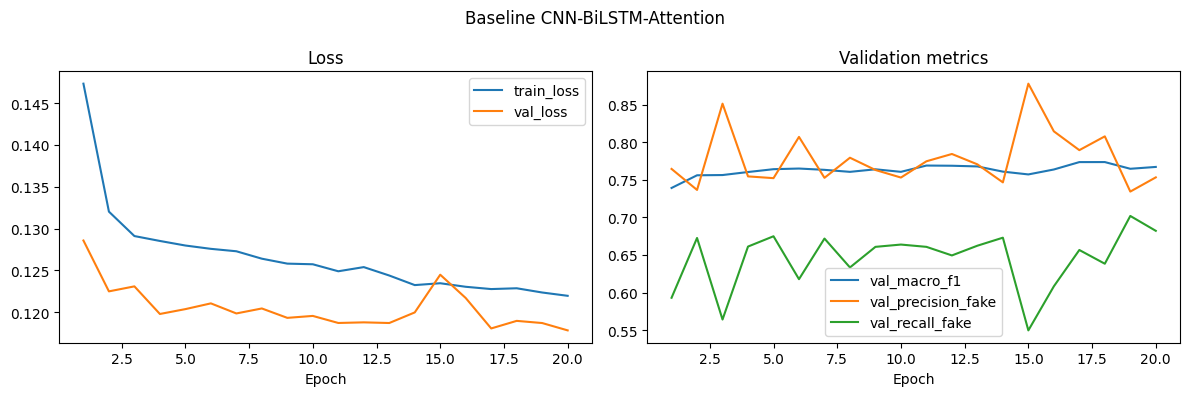

,generated_at_utc,seed,split,model_variant,threshold,loss,accuracy,macro_f1,precision_fake,recall_fake,f1_fake,support_real,support_fake,roc_auc,pr_auc,tn,fp,fn,tp,probability_path
0,2026-06-01T08:09:11.977160+00:00,42,train,dl_baseline,0.5,0.118537,0.787020,0.772678,0.788997,0.654663,0.715580,17677,12246,0.842763,0.830222,15533,2144,4229,8017,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...
1,2026-06-01T08:09:12.695418+00:00,42,val,dl_baseline,0.5,0.118063,0.787931,0.773722,0.789643,0.656631,0.717020,3789,2624,0.838348,0.829885,3330,459,901,1723,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...
2,2026-06-01T08:09:13.281155+00:00,42,test,dl_baseline,0.5,0.119523,0.781382,0.766460,0.781827,0.645960,0.707429,3789,2624,0.838937,0.824163,3316,473,929,1695,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...


In [10]:
# BASELINE_CONFIG: hyperparameter mặc định cho baseline MLP (không PSO)
BASELINE_CONFIG = {
    # "learning_rate": 1e-3,: thực thi lệnh Python
    "learning_rate": 1e-3,
    # "dropout": 0.30,: thực thi lệnh Python
    "dropout": 0.30,
    # "cnn_filters": 64,: thực thi lệnh Python
    "cnn_filters": 64,
    # "kernel_size": 5,: thực thi lệnh Python
    "kernel_size": 5,
    # "lstm_hidden": 64,: thực thi lệnh Python
    "lstm_hidden": 64,
    # "attention_dim": 64,: thực thi lệnh Python
    "attention_dim": 64,
    # "focal_gamma": 2.0,: thực thi lệnh Python
    "focal_gamma": 2.0,
    # "batch_size": DEFAULT_BATCH_SIZE,: thực thi lệnh Python
    "batch_size": DEFAULT_BATCH_SIZE,
    # "component_block_weights": [1.0, 1.0, 1.0, 1.0],: thực thi lệnh Python
    "component_block_weights": [1.0, 1.0, 1.0, 1.0],
# }: đóng khối từ điển
}

# baseline_batch_size = ...: ép kiểu số nguyên
baseline_batch_size = capped_batch_size(int(BASELINE_CONFIG["batch_size"]))
# baseline_train_loader = ...: gán giá trị cho biến baseline train loader
baseline_train_loader = make_loader(X["train"], y["train"], baseline_batch_size, shuffle=True)
# baseline_val_loader = ...: gán giá trị cho biến baseline val loader
baseline_val_loader = make_loader(X["val"], y["val"], baseline_batch_size, shuffle=False)
# baseline_test_loader = ...: gán giá trị cho biến baseline test loader
baseline_test_loader = make_loader(X["test"], y["test"], baseline_batch_size, shuffle=False)

# baseline_model, baseline_history_df, baseline_best_metrics = fit_model(: fit model/reducer trên dữ liệu train
baseline_model, baseline_history_df, baseline_best_metrics = fit_model(
    # config = ...: gán giá trị cho biến config
    config=BASELINE_CONFIG,
    # train_data_loader = ...: gán giá trị cho biến train data loader
    train_data_loader=baseline_train_loader,
    # validation_data_loader = ...: gán giá trị cho biến validation data loader
    validation_data_loader=baseline_val_loader,
    # class_weights = ...: gán giá trị cho biến class weights
    class_weights=CLASS_WEIGHTS,
    # input_dim = ...: gán giá trị cho biến input dim
    input_dim=INPUT_DIM,
    # model_variant = ...: gán giá trị cho biến model variant
    model_variant="dl_baseline",
    # max_epochs = ...: lấy giá trị lớn nhất
    max_epochs=BASELINE_MAX_EPOCHS,
    # patience = ...: gán giá trị cho biến patience
    patience=EARLY_STOPPING_PATIENCE,
    # verbose = ...: gán giá trị cho biến verbose
    verbose=True,
# ): đóng ngoặc gọi hàm
)

# torch.save(: thực thi lệnh Python
torch.save(
    # {: thực thi lệnh Python
    {
        # "model_variant": "dl_baseline",: thực thi lệnh Python
        "model_variant": "dl_baseline",
        # "seed": SEED,: thực thi lệnh Python
        "seed": SEED,
        # "input_dim": INPUT_DIM,: thực thi lệnh Python
        "input_dim": INPUT_DIM,
        # "config": BASELINE_CONFIG,: thực thi lệnh Python
        "config": BASELINE_CONFIG,
        # "class_weights": CLASS_WEIGHTS.tolist(),: chuyển/chiếu thành list
        "class_weights": CLASS_WEIGHTS.tolist(),
        # "best_validation_metrics": baseline_best_metrics,: thực thi lệnh Python
        "best_validation_metrics": baseline_best_metrics,
        # "model_state_dict": {key: value.detach().cpu() for key, value in baseline_model....: tạo dictionary
        "model_state_dict": {key: value.detach().cpu() for key, value in baseline_model.state_dict().items()},
    # },: đóng phần tử từ điển (còn phần tử sau)
    },
    # BASELINE_MODEL_PATH,: thực thi lệnh Python
    BASELINE_MODEL_PATH,
# ): đóng ngoặc gọi hàm
)

# baseline_history_path = ...: gán giá trị cho biến baseline history path
baseline_history_path = REPORT_TABLE_DIR / "phase4_baseline_training_history.csv"
# baseline_history_df.to_csv(baseline_history_path, index=False): ghi DataFrame ra file CSV
baseline_history_df.to_csv(baseline_history_path, index=False)

# baseline_metrics_rows = ...: gán giá trị cho biến baseline metrics rows
baseline_metrics_rows = []
# baseline_criterion = ...: gán giá trị cho biến baseline criterion
baseline_criterion = FocalLoss(alpha=CLASS_WEIGHTS.to(DEVICE), gamma=BASELINE_CONFIG["focal_gamma"])
# for: vòng lặp — for split, loader in [
for split, loader in [
    # ("train", baseline_train_loader),: thực thi lệnh Python
    ("train", baseline_train_loader),
    # ("val", baseline_val_loader),: thực thi lệnh Python
    ("val", baseline_val_loader),
    # ("test", baseline_test_loader),: thực thi lệnh Python
    ("test", baseline_test_loader),
# ]:: thực thi lệnh Python
]:
    # metrics, prob_fake, _ = evaluate_model(baseline_model, loader, baseline_criterio...: thực thi lệnh Python
    metrics, prob_fake, _ = evaluate_model(baseline_model, loader, baseline_criterion, split, "dl_baseline")
    # metrics["probability_path"] = save_probabilities(prob_fake, split, "dl_baseline"...: thực thi lệnh Python
    metrics["probability_path"] = save_probabilities(prob_fake, split, "dl_baseline")
    # baseline_metrics_rows.append(metrics): thực thi lệnh Python
    baseline_metrics_rows.append(metrics)

# baseline_metrics_df = ...: gán giá trị cho biến baseline metrics df
baseline_metrics_df = pd.DataFrame(baseline_metrics_rows)
# baseline_metrics_path = ...: gán giá trị cho biến baseline metrics path
baseline_metrics_path = REPORT_TABLE_DIR / "phase4_baseline_metrics.csv"
# baseline_metrics_df.to_csv(baseline_metrics_path, index=False): ghi DataFrame ra file CSV
baseline_metrics_df.to_csv(baseline_metrics_path, index=False)

# plot_training_history(: thực thi lệnh Python
plot_training_history(
    # baseline_history_df,: thực thi lệnh Python
    baseline_history_df,
    # REPORT_FIGURE_DIR / "phase4_baseline_training_curves.png",: thực thi lệnh Python
    REPORT_FIGURE_DIR / "phase4_baseline_training_curves.png",
    # "Baseline CNN-BiLSTM-Attention",: thực thi lệnh Python
    "Baseline CNN-BiLSTM-Attention",
# ): đóng ngoặc gọi hàm
)
# display(baseline_metrics_df): hiển thị bảng/kết quả trên notebook
display(baseline_metrics_df)


## 5. PSO search on deterministic 20% subset

The PSO objective optimizes validation Macro F1. The search space includes model hyperparameters and four lightweight PCA component-block weights.

In [11]:
# PSO_SEARCH_SPACE: biến cấu hình/hằng số của notebook
PSO_SEARCH_SPACE = {
    # "learning_rate": (1e-4, 5e-3),: thực thi lệnh Python
    "learning_rate": (1e-4, 5e-3),
    # "dropout": (0.10, 0.40),: thực thi lệnh Python
    "dropout": (0.10, 0.40),
    # "cnn_filters": (64, 192),: thực thi lệnh Python
    "cnn_filters": (64, 192),
    # "kernel_size": (3, 7),: thực thi lệnh Python
    "kernel_size": (3, 7),
    # "lstm_hidden": (64, 128),: thực thi lệnh Python
    "lstm_hidden": (64, 128),
    # "attention_dim": (64, 128),: thực thi lệnh Python
    "attention_dim": (64, 128),
    # "focal_gamma": (1.0, 3.0),: thực thi lệnh Python
    "focal_gamma": (1.0, 3.0),
    # "batch_size": (32, 64),: thực thi lệnh Python
    "batch_size": (32, 64),
    # "pca_block_weight_1": (0.60, 1.50),: thực thi lệnh Python
    "pca_block_weight_1": (0.60, 1.50),
    # "pca_block_weight_2": (0.60, 1.50),: thực thi lệnh Python
    "pca_block_weight_2": (0.60, 1.50),
    # "pca_block_weight_3": (0.60, 1.50),: thực thi lệnh Python
    "pca_block_weight_3": (0.60, 1.50),
    # "pca_block_weight_4": (0.60, 1.50),: thực thi lệnh Python
    "pca_block_weight_4": (0.60, 1.50),
# }: đóng khối từ điển
}

# PSO_OBJECTIVE_WEIGHTS: biến cấu hình/hằng số của notebook
PSO_OBJECTIVE_WEIGHTS = {
    # "macro_f1": 0.50,: thực thi lệnh Python
    "macro_f1": 0.50,
    # "roc_auc": 0.30,: thực thi lệnh Python
    "roc_auc": 0.30,
    # "precision_fake": 0.20,: thực thi lệnh Python
    "precision_fake": 0.20,
# }: đóng khối từ điển
}

# PSO_PARAM_NAMES: biến cấu hình/hằng số của notebook
PSO_PARAM_NAMES = [
    # "log10_learning_rate",: thực thi lệnh Python
    "log10_learning_rate",
    # "dropout",: thực thi lệnh Python
    "dropout",
    # "cnn_filters_continuous",: thực thi lệnh Python
    "cnn_filters_continuous",
    # "kernel_size_continuous",: thực thi lệnh Python
    "kernel_size_continuous",
    # "lstm_hidden_continuous",: thực thi lệnh Python
    "lstm_hidden_continuous",
    # "attention_dim_continuous",: thực thi lệnh Python
    "attention_dim_continuous",
    # "focal_gamma",: thực thi lệnh Python
    "focal_gamma",
    # "batch_size_continuous",: thực thi lệnh Python
    "batch_size_continuous",
    # "pca_block_weight_1",: thực thi lệnh Python
    "pca_block_weight_1",
    # "pca_block_weight_2",: thực thi lệnh Python
    "pca_block_weight_2",
    # "pca_block_weight_3",: thực thi lệnh Python
    "pca_block_weight_3",
    # "pca_block_weight_4",: thực thi lệnh Python
    "pca_block_weight_4",
# ]: đóng khối danh sách
]
# PSO_LOWER_BOUNDS: biến cấu hình/hằng số của notebook
PSO_LOWER_BOUNDS = np.array(
    # [: thực thi lệnh Python
    [
        # math.log10(PSO_SEARCH_SPACE["learning_rate"][0]),: thực thi lệnh Python
        math.log10(PSO_SEARCH_SPACE["learning_rate"][0]),
        # PSO_SEARCH_SPACE["dropout"][0],: thực thi lệnh Python
        PSO_SEARCH_SPACE["dropout"][0],
        # PSO_SEARCH_SPACE["cnn_filters"][0],: thực thi lệnh Python
        PSO_SEARCH_SPACE["cnn_filters"][0],
        # PSO_SEARCH_SPACE["kernel_size"][0],: thực thi lệnh Python
        PSO_SEARCH_SPACE["kernel_size"][0],
        # PSO_SEARCH_SPACE["lstm_hidden"][0],: thực thi lệnh Python
        PSO_SEARCH_SPACE["lstm_hidden"][0],
        # PSO_SEARCH_SPACE["attention_dim"][0],: thực thi lệnh Python
        PSO_SEARCH_SPACE["attention_dim"][0],
        # PSO_SEARCH_SPACE["focal_gamma"][0],: thực thi lệnh Python
        PSO_SEARCH_SPACE["focal_gamma"][0],
        # PSO_SEARCH_SPACE["batch_size"][0],: thực thi lệnh Python
        PSO_SEARCH_SPACE["batch_size"][0],
        # PSO_SEARCH_SPACE["pca_block_weight_1"][0],: thực thi lệnh Python
        PSO_SEARCH_SPACE["pca_block_weight_1"][0],
        # PSO_SEARCH_SPACE["pca_block_weight_2"][0],: thực thi lệnh Python
        PSO_SEARCH_SPACE["pca_block_weight_2"][0],
        # PSO_SEARCH_SPACE["pca_block_weight_3"][0],: thực thi lệnh Python
        PSO_SEARCH_SPACE["pca_block_weight_3"][0],
        # PSO_SEARCH_SPACE["pca_block_weight_4"][0],: thực thi lệnh Python
        PSO_SEARCH_SPACE["pca_block_weight_4"][0],
    # ],: đóng phần tử danh sách (còn phần tử sau)
    ],
    # dtype = ...: ép kiểu số thực
    dtype=float,
# ): đóng ngoặc gọi hàm
)
# PSO_UPPER_BOUNDS: biến cấu hình/hằng số của notebook
PSO_UPPER_BOUNDS = np.array(
    # [: thực thi lệnh Python
    [
        # math.log10(PSO_SEARCH_SPACE["learning_rate"][1]),: thực thi lệnh Python
        math.log10(PSO_SEARCH_SPACE["learning_rate"][1]),
        # PSO_SEARCH_SPACE["dropout"][1],: thực thi lệnh Python
        PSO_SEARCH_SPACE["dropout"][1],
        # PSO_SEARCH_SPACE["cnn_filters"][1],: thực thi lệnh Python
        PSO_SEARCH_SPACE["cnn_filters"][1],
        # PSO_SEARCH_SPACE["kernel_size"][1],: thực thi lệnh Python
        PSO_SEARCH_SPACE["kernel_size"][1],
        # PSO_SEARCH_SPACE["lstm_hidden"][1],: thực thi lệnh Python
        PSO_SEARCH_SPACE["lstm_hidden"][1],
        # PSO_SEARCH_SPACE["attention_dim"][1],: thực thi lệnh Python
        PSO_SEARCH_SPACE["attention_dim"][1],
        # PSO_SEARCH_SPACE["focal_gamma"][1],: thực thi lệnh Python
        PSO_SEARCH_SPACE["focal_gamma"][1],
        # PSO_SEARCH_SPACE["batch_size"][1],: thực thi lệnh Python
        PSO_SEARCH_SPACE["batch_size"][1],
        # PSO_SEARCH_SPACE["pca_block_weight_1"][1],: thực thi lệnh Python
        PSO_SEARCH_SPACE["pca_block_weight_1"][1],
        # PSO_SEARCH_SPACE["pca_block_weight_2"][1],: thực thi lệnh Python
        PSO_SEARCH_SPACE["pca_block_weight_2"][1],
        # PSO_SEARCH_SPACE["pca_block_weight_3"][1],: thực thi lệnh Python
        PSO_SEARCH_SPACE["pca_block_weight_3"][1],
        # PSO_SEARCH_SPACE["pca_block_weight_4"][1],: thực thi lệnh Python
        PSO_SEARCH_SPACE["pca_block_weight_4"][1],
    # ],: đóng phần tử danh sách (còn phần tử sau)
    ],
    # dtype = ...: ép kiểu số thực
    dtype=float,
# ): đóng ngoặc gọi hàm
)


# nearest_choice: làm tròn giá trị PSO về lựa chọn rời rạc gần nhất
def nearest_choice(value: float, choices: list[int]) -> int:
    # return: trả kết quả từ hàm
    return int(min(choices, key=lambda choice: abs(choice - value)))


# decode_particle: chuyển vector particle PSO thành dict hyperparameter
def decode_particle(position: np.ndarray | list[float]) -> dict:
    # position = ...: ép kiểu số thực
    position = np.asarray(position, dtype=float)
    # kernel_size = ...: gán giá trị cho biến kernel size
    kernel_size = nearest_choice(position[3], [3, 5, 7])
    # return: trả kết quả từ hàm
    return {
        # "learning_rate": float(10 ** position[0]),: ép kiểu số thực
        "learning_rate": float(10 ** position[0]),
        # "dropout": float(np.clip(position[1], *PSO_SEARCH_SPACE["dropout"])),: ép kiểu số thực
        "dropout": float(np.clip(position[1], *PSO_SEARCH_SPACE["dropout"])),
        # "cnn_filters": nearest_choice(position[2], [64, 96, 128, 160, 192]),: thực thi lệnh Python
        "cnn_filters": nearest_choice(position[2], [64, 96, 128, 160, 192]),
        # "kernel_size": kernel_size,: thực thi lệnh Python
        "kernel_size": kernel_size,
        # "lstm_hidden": nearest_choice(position[4], [64, 96, 128]),: thực thi lệnh Python
        "lstm_hidden": nearest_choice(position[4], [64, 96, 128]),
        # "attention_dim": nearest_choice(position[5], [64, 96, 128]),: thực thi lệnh Python
        "attention_dim": nearest_choice(position[5], [64, 96, 128]),
        # "focal_gamma": float(np.clip(position[6], *PSO_SEARCH_SPACE["focal_gamma"])),: ép kiểu số thực
        "focal_gamma": float(np.clip(position[6], *PSO_SEARCH_SPACE["focal_gamma"])),
        # "batch_size": capped_batch_size(nearest_choice(position[7], [32, 48, 64])),: thực thi lệnh Python
        "batch_size": capped_batch_size(nearest_choice(position[7], [32, 48, 64])),
        # "component_block_weights": [float(v) for v in np.clip(position[8:12], 0.60, 1.50...: ép kiểu số thực
        "component_block_weights": [float(v) for v in np.clip(position[8:12], 0.60, 1.50)],
    # }: đóng khối từ điển
    }


# compute_pso_objective_score: hàm mục tiêu PSO (ưu tiên macro F1 / precision fake)
def compute_pso_objective_score(metrics: dict) -> float:
    # return: trả kết quả từ hàm
    return float(
        # PSO_OBJECTIVE_WEIGHTS["macro_f1"] * float(metrics["macro_f1"]): ép kiểu số thực
        PSO_OBJECTIVE_WEIGHTS["macro_f1"] * float(metrics["macro_f1"])
        # + PSO_OBJECTIVE_WEIGHTS["roc_auc"] * float(metrics["roc_auc"]): ép kiểu số thực
        + PSO_OBJECTIVE_WEIGHTS["roc_auc"] * float(metrics["roc_auc"])
        # + PSO_OBJECTIVE_WEIGHTS["precision_fake"] * float(metrics["precision_fake"]): ép kiểu số thực
        + PSO_OBJECTIVE_WEIGHTS["precision_fake"] * float(metrics["precision_fake"])
    # ): đóng ngoặc gọi hàm
    )


# splitter = ...: gán giá trị cho biến splitter
splitter = StratifiedShuffleSplit(n_splits=1, train_size=PSO_SUBSET_RATIO, random_state=SEED)
# pso_subset_idx, _ = next(splitter.split(X["train"], y["train"])): tạo tập hợp
pso_subset_idx, _ = next(splitter.split(X["train"], y["train"]))
# X_train_pso = ...: tạo tập hợp
X_train_pso = X["train"][pso_subset_idx]
# y_train_pso = ...: tạo tập hợp
y_train_pso = y["train"][pso_subset_idx]

# print("PSO subset rows:", len(pso_subset_idx), "of", len(y["train"])): in thông tin ra console
print("PSO subset rows:", len(pso_subset_idx), "of", len(y["train"]))
# print("PSO search space:", PSO_SEARCH_SPACE): in thông tin ra console
print("PSO search space:", PSO_SEARCH_SPACE)
# print("PSO objective weights:", PSO_OBJECTIVE_WEIGHTS): in thông tin ra console
print("PSO objective weights:", PSO_OBJECTIVE_WEIGHTS)
# print("PSO bounds:", dict(zip(PSO_PARAM_NAMES, zip(PSO_LOWER_BOUNDS, PSO_UPPER_B...: in thông tin ra console
print("PSO bounds:", dict(zip(PSO_PARAM_NAMES, zip(PSO_LOWER_BOUNDS, PSO_UPPER_BOUNDS))))


PSO subset rows: 5984 of 29923
PSO search space: {'learning_rate': (0.0001, 0.005), 'dropout': (0.1, 0.4), 'cnn_filters': (64, 192), 'kernel_size': (3, 7), 'lstm_hidden': (64, 128), 'attention_dim': (64, 128), 'focal_gamma': (1.0, 3.0), 'batch_size': (32, 64), 'pca_block_weight_1': (0.6, 1.5), 'pca_block_weight_2': (0.6, 1.5), 'pca_block_weight_3': (0.6, 1.5), 'pca_block_weight_4': (0.6, 1.5)}
PSO objective weights: {'macro_f1': 0.5, 'roc_auc': 0.3, 'precision_fake': 0.2}
PSO bounds: {'log10_learning_rate': (np.float64(-4.0), np.float64(-2.3010299956639813)), 'dropout': (np.float64(0.1), np.float64(0.4)), 'cnn_filters_continuous': (np.float64(64.0), np.float64(192.0)), 'kernel_size_continuous': (np.float64(3.0), np.float64(7.0)), 'lstm_hidden_continuous': (np.float64(64.0), np.float64(128.0)), 'attention_dim_continuous': (np.float64(64.0), np.float64(128.0)), 'focal_gamma': (np.float64(1.0), np.float64(3.0)), 'batch_size_continuous': (np.float64(32.0), np.float64(64.0)), 'pca_block_wei

In [12]:
# PSO_TRIAL_HISTORY: biến cấu hình/hằng số của notebook
PSO_TRIAL_HISTORY = []


# pso_objective: train thử với hyperparameter từ particle, trả điểm (càng thấp càng tốt)
def pso_objective(position: np.ndarray | list[float]) -> float:
    # trial_number = ...: đếm số phần tử
    trial_number = len(PSO_TRIAL_HISTORY) + 1
    # config = ...: gán giá trị cho biến config
    config = decode_particle(position)
    # config["batch_size"] = capped_batch_size(int(config.get("batch_size", DEFAULT_BA...: ép kiểu số nguyên
    config["batch_size"] = capped_batch_size(int(config.get("batch_size", DEFAULT_BATCH_SIZE)))
    # model = ...: xóa biến để giải phóng RAM/VRAM
    model = None
    # history_df = ...: gán giá trị cho biến history df
    history_df = None
    # start_time = ...: gán giá trị cho biến start time
    start_time = time.time()
    # status = ...: gán giá trị cho biến status
    status = "ok"
    # objective = ...: gán giá trị cho biến objective
    objective = 1.0
    # best_macro_f1 = ...: gán giá trị cho biến best macro f1
    best_macro_f1 = 0.0
    # best_precision_fake = ...: gán giá trị cho biến best precision fake
    best_precision_fake = 0.0
    # best_roc_auc = ...: gán giá trị cho biến best roc auc
    best_roc_auc = 0.0
    # best_objective_score = ...: gán giá trị cho biến best objective score
    best_objective_score = 0.0

    # try/except: khối xử lý ngoại lệ
    try:
        # gc.collect(): giải phóng bộ nhớ
        gc.collect()
        # if: điều kiện — if torch.cuda.is_available():
        if torch.cuda.is_available():
            # torch.cuda.empty_cache(): thực thi lệnh Python
            torch.cuda.empty_cache()
        # trial_train_loader = ...: gán giá trị cho biến trial train loader
        trial_train_loader = make_loader(X_train_pso, y_train_pso, config["batch_size"], shuffle=True)
        # trial_val_loader = ...: gán giá trị cho biến trial val loader
        trial_val_loader = make_loader(X["val"], y["val"], config["batch_size"], shuffle=False)
        # model, history_df, best_metrics = fit_model(: fit model/reducer trên dữ liệu train
        model, history_df, best_metrics = fit_model(
            # config = ...: gán giá trị cho biến config
            config=config,
            # train_data_loader = ...: gán giá trị cho biến train data loader
            train_data_loader=trial_train_loader,
            # validation_data_loader = ...: gán giá trị cho biến validation data loader
            validation_data_loader=trial_val_loader,
            # class_weights = ...: gán giá trị cho biến class weights
            class_weights=CLASS_WEIGHTS,
            # input_dim = ...: gán giá trị cho biến input dim
            input_dim=INPUT_DIM,
            # model_variant = ...: gán giá trị cho biến model variant
            model_variant=f"pso_trial_{trial_number:03d}",
            # max_epochs = ...: lấy giá trị lớn nhất
            max_epochs=PSO_TRIAL_EPOCHS,
            # patience = ...: lấy giá trị nhỏ nhất
            patience=min(EARLY_STOPPING_PATIENCE, PSO_TRIAL_EPOCHS),
            # verbose = ...: gán giá trị cho biến verbose
            verbose=False,
        # ): đóng ngoặc gọi hàm
        )
        # best_macro_f1 = ...: ép kiểu số thực
        best_macro_f1 = float(best_metrics["macro_f1"])
        # best_precision_fake = ...: ép kiểu số thực
        best_precision_fake = float(best_metrics["precision_fake"])
        # best_roc_auc = ...: ép kiểu số thực
        best_roc_auc = float(best_metrics["roc_auc"])
        # best_objective_score = ...: gán giá trị cho biến best objective score
        best_objective_score = compute_pso_objective_score(best_metrics)
        # objective = ...: gán giá trị cho biến objective
        objective = -best_objective_score
    # except: xử lý ngoại lệ — except Exception as exc:
    except Exception as exc:
        # status = ...: ép kiểu chuỗi
        status = f"failed:{type(exc).__name__}:{str(exc)[:160]}"
        # objective = ...: gán giá trị cho biến objective
        objective = 1.0
        # best_macro_f1 = ...: gán giá trị cho biến best macro f1
        best_macro_f1 = 0.0
        # best_precision_fake = ...: gán giá trị cho biến best precision fake
        best_precision_fake = 0.0
        # best_roc_auc = ...: gán giá trị cho biến best roc auc
        best_roc_auc = 0.0
        # best_objective_score = ...: gán giá trị cho biến best objective score
        best_objective_score = 0.0
    # finally:: thực thi lệnh Python
    finally:
        # elapsed_sec = ...: gán giá trị cho biến elapsed sec
        elapsed_sec = time.time() - start_time
        # row = ...: gán giá trị cho biến row
        row = {
            # "generated_at_utc": utc_now(),: thực thi lệnh Python
            "generated_at_utc": utc_now(),
            # "seed": SEED,: thực thi lệnh Python
            "seed": SEED,
            # "trial": int(trial_number),: ép kiểu số nguyên
            "trial": int(trial_number),
            # "status": status,: thực thi lệnh Python
            "status": status,
            # "objective": float(objective),: ép kiểu số thực
            "objective": float(objective),
            # "best_val_macro_f1": float(best_macro_f1),: ép kiểu số thực
            "best_val_macro_f1": float(best_macro_f1),
            # "best_val_precision_fake": float(best_precision_fake),: ép kiểu số thực
            "best_val_precision_fake": float(best_precision_fake),
            # "best_val_roc_auc": float(best_roc_auc),: ép kiểu số thực
            "best_val_roc_auc": float(best_roc_auc),
            # "best_val_objective_score": float(best_objective_score),: ép kiểu số thực
            "best_val_objective_score": float(best_objective_score),
            # "elapsed_sec": float(elapsed_sec),: ép kiểu số thực
            "elapsed_sec": float(elapsed_sec),
            # "pso_subset_ratio": PSO_SUBSET_RATIO,: tạo tập hợp
            "pso_subset_ratio": PSO_SUBSET_RATIO,
            # "pso_subset_rows": int(len(pso_subset_idx)),: đếm số phần tử
            "pso_subset_rows": int(len(pso_subset_idx)),
            # "model_variant": f"pso_trial_{trial_number:03d}",: thực thi lệnh Python
            "model_variant": f"pso_trial_{trial_number:03d}",
            # **config,: thực thi lệnh Python
            **config,
        # }: đóng khối từ điển
        }
        # PSO_TRIAL_HISTORY.append(row): thực thi lệnh Python
        PSO_TRIAL_HISTORY.append(row)
        # pd.DataFrame(PSO_TRIAL_HISTORY).to_csv(: ghi DataFrame ra file CSV
        pd.DataFrame(PSO_TRIAL_HISTORY).to_csv(
            # REPORT_TABLE_DIR / "phase4_pso_trial_history.csv",: thực thi lệnh Python
            REPORT_TABLE_DIR / "phase4_pso_trial_history.csv",
            # index = ...: gán giá trị cho biến index
            index=False,
        # ): đóng ngoặc gọi hàm
        )
        # if: điều kiện — if history_df is not None:
        if history_df is not None:
            # history_df.to_csv(: ghi DataFrame ra file CSV
            history_df.to_csv(
                # REPORT_TABLE_DIR / f"phase4_pso_trial_{trial_number:03d}_history.csv",: thực thi lệnh Python
                REPORT_TABLE_DIR / f"phase4_pso_trial_{trial_number:03d}_history.csv",
                # index = ...: gán giá trị cho biến index
                index=False,
            # ): đóng ngoặc gọi hàm
            )
        # del model: xóa biến để giải phóng RAM/VRAM
        del model
        # del history_df: xóa biến để giải phóng RAM/VRAM
        del history_df
        # gc.collect(): giải phóng bộ nhớ
        gc.collect()
        # if: điều kiện — if torch.cuda.is_available():
        if torch.cuda.is_available():
            # torch.cuda.empty_cache(): thực thi lệnh Python
            torch.cuda.empty_cache()
        # print(: in thông tin ra console
        print(
            # f"PSO trial {trial_number:03d}: status={status}, ": thực thi lệnh Python
            f"PSO trial {trial_number:03d}: status={status}, "
            # f"val_macro_f1={best_macro_f1:.4f}, ": thực thi lệnh Python
            f"val_macro_f1={best_macro_f1:.4f}, "
            # f"val_roc_auc={best_roc_auc:.4f}, ": thực thi lệnh Python
            f"val_roc_auc={best_roc_auc:.4f}, "
            # f"val_precision_fake={best_precision_fake:.4f}, ": thực thi lệnh Python
            f"val_precision_fake={best_precision_fake:.4f}, "
            # f"objective_score={best_objective_score:.4f}": thực thi lệnh Python
            f"objective_score={best_objective_score:.4f}"
        # ): đóng ngoặc gọi hàm
        )
    # return: trả kết quả từ hàm
    return float(objective)


PSO trial 001: status=ok, val_macro_f1=0.7588, val_roc_auc=0.8161, val_precision_fake=0.7916, objective_score=0.7826
PSO trial 002: status=ok, val_macro_f1=0.7354, val_roc_auc=0.7717, val_precision_fake=0.8824, objective_score=0.7757
PSO trial 003: status=ok, val_macro_f1=0.7339, val_roc_auc=0.7826, val_precision_fake=0.8166, objective_score=0.7651
PSO trial 004: status=ok, val_macro_f1=0.7655, val_roc_auc=0.8260, val_precision_fake=0.7939, objective_score=0.7893
PSO trial 005: status=ok, val_macro_f1=0.7534, val_roc_auc=0.8111, val_precision_fake=0.7361, objective_score=0.7673
PSO trial 006: status=ok, val_macro_f1=0.7323, val_roc_auc=0.7694, val_precision_fake=0.8490, objective_score=0.7667
PSO trial 007: status=ok, val_macro_f1=0.7439, val_roc_auc=0.8086, val_precision_fake=0.7445, objective_score=0.7634
PSO trial 008: status=ok, val_macro_f1=0.7325, val_roc_auc=0.8019, val_precision_fake=0.6912, objective_score=0.7451
PSO trial 009: status=ok, val_macro_f1=0.7444, val_roc_auc=0.806

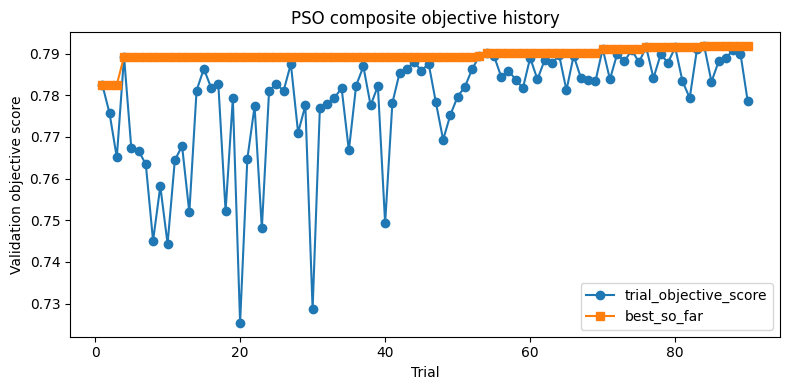

Best PSO validation objective score: 0.7917960225596838
Best PSO validation Macro F1: 0.7662583218789658
Saved best params: /content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/artifacts/models/best_params.json


In [13]:
# fallback_pso: PSO thủ công nếu thư viện pyswarm không khả dụng
def fallback_pso(func, lb, ub, swarmsize: int, maxiter: int, debug: bool = False):
    # rng = ...: gán giá trị cho biến rng
    rng = np.random.default_rng(SEED)
    # lb = ...: ép kiểu số thực
    lb = np.asarray(lb, dtype=float)
    # ub = ...: ép kiểu số thực
    ub = np.asarray(ub, dtype=float)
    # positions = ...: đếm số phần tử
    positions = rng.uniform(lb, ub, size=(swarmsize, len(lb)))
    # best_position = ...: gán giá trị cho biến best position
    best_position = None
    # best_value = ...: gán giá trị cho biến best value
    best_value = np.inf

    # for: vòng lặp — for iteration in range(maxiter + 1):
    for iteration in range(maxiter + 1):
        # for: vòng lặp — for position in positions:
        for position in positions:
            # value = ...: ép kiểu số thực
            value = float(func(position))
            # if: điều kiện — if value < best_value:
            if value < best_value:
                # best_value = ...: gán giá trị cho biến best value
                best_value = value
                # best_position = ...: ép kiểu số thực
                best_position = np.asarray(position, dtype=float).copy()
        # span = ...: lấy giá trị lớn nhất
        span = (ub - lb) * max(0.10, 0.50 ** (iteration + 1))
        # positions = ...: gán giá trị cho biến positions
        positions = np.clip(
            # best_position + rng.normal(loc=0.0, scale=span, size=(swarmsize, len(lb))),: đếm số phần tử
            best_position + rng.normal(loc=0.0, scale=span, size=(swarmsize, len(lb))),
            # lb,: thực thi lệnh Python
            lb,
            # ub,: thực thi lệnh Python
            ub,
        # ): đóng ngoặc gọi hàm
        )
        # if: điều kiện — if debug:
        if debug:
            # print("fallback_pso iteration", iteration, "best", best_value): in thông tin ra console
            print("fallback_pso iteration", iteration, "best", best_value)
    # return: trả kết quả từ hàm
    return best_position, best_value


# normalize_pso_result: chuẩn hóa output PSO về format thống nhất
def normalize_pso_result(result):
    # if: điều kiện — if isinstance(result, dict):
    if isinstance(result, dict):
        # position = ...: gán giá trị cho biến position
        position = result.get("best_position", result.get("x", result.get("position")))
        # objective = ...: gán giá trị cho biến objective
        objective = result.get("best_objective", result.get("fun", result.get("objective")))
    # elif: nhánh điều kiện phụ — elif isinstance(result, (tuple, list)):
    elif isinstance(result, (tuple, list)):
        # if: điều kiện — if len(result) < 2:
        if len(result) < 2:
            # raise ValueError(f"PSO returned too few values: {result}"): trả kết quả từ hàm
            raise ValueError(f"PSO returned too few values: {result}")
        # position, objective = result[0], result[1]: thực thi lệnh Python
        position, objective = result[0], result[1]
    # else: nhánh còn lại của điều kiện
    else:
        # raise TypeError(f"Unsupported PSO return type: {type(result)}"): trả kết quả từ hàm
        raise TypeError(f"Unsupported PSO return type: {type(result)}")

    # if: điều kiện — if position is None or objective is None:
    if position is None or objective is None:
        # raise ValueError(f"Could not unpack PSO result: {result}"): ném lỗi và dừng cell
        raise ValueError(f"Could not unpack PSO result: {result}")
    # return: trả kết quả từ hàm
    return np.asarray(position, dtype=float), float(np.asarray(objective).reshape(-1)[0])


# if: điều kiện — if pyswarm_pso is not None:
if pyswarm_pso is not None:
    # pso_result = ...: gán giá trị cho biến pso result
    pso_result = pyswarm_pso(
        # pso_objective,: thực thi lệnh Python
        pso_objective,
        # PSO_LOWER_BOUNDS,: thực thi lệnh Python
        PSO_LOWER_BOUNDS,
        # PSO_UPPER_BOUNDS,: thực thi lệnh Python
        PSO_UPPER_BOUNDS,
        # swarmsize = ...: gán giá trị cho biến swarmsize
        swarmsize=PSO_PARTICLES,
        # maxiter = ...: lấy giá trị lớn nhất
        maxiter=PSO_ITERATIONS,
        # debug = ...: gán giá trị cho biến debug
        debug=False,
    # ): đóng ngoặc gọi hàm
    )
    # best_position, best_objective = normalize_pso_result(pso_result): thực thi lệnh Python
    best_position, best_objective = normalize_pso_result(pso_result)
# else: nhánh còn lại của điều kiện
else:
    # print("pyswarm unavailable; using bounded fallback search. Error:", PYSWARM_IMPO...: in thông tin ra console
    print("pyswarm unavailable; using bounded fallback search. Error:", PYSWARM_IMPORT_ERROR)
    # pso_result = ...: gán giá trị cho biến pso result
    pso_result = fallback_pso(
        # pso_objective,: thực thi lệnh Python
        pso_objective,
        # PSO_LOWER_BOUNDS,: thực thi lệnh Python
        PSO_LOWER_BOUNDS,
        # PSO_UPPER_BOUNDS,: thực thi lệnh Python
        PSO_UPPER_BOUNDS,
        # swarmsize = ...: gán giá trị cho biến swarmsize
        swarmsize=PSO_PARTICLES,
        # maxiter = ...: lấy giá trị lớn nhất
        maxiter=PSO_ITERATIONS,
        # debug = ...: gán giá trị cho biến debug
        debug=False,
    # ): đóng ngoặc gọi hàm
    )
    # best_position, best_objective = normalize_pso_result(pso_result): thực thi lệnh Python
    best_position, best_objective = normalize_pso_result(pso_result)

# pso_trial_history_df = ...: gán giá trị cho biến pso trial history df
pso_trial_history_df = pd.DataFrame(PSO_TRIAL_HISTORY)
# pso_trial_history_path = ...: gán giá trị cho biến pso trial history path
pso_trial_history_path = REPORT_TABLE_DIR / "phase4_pso_trial_history.csv"
# pso_trial_history_df.to_csv(pso_trial_history_path, index=False): ghi DataFrame ra file CSV
pso_trial_history_df.to_csv(pso_trial_history_path, index=False)

# valid_pso_trials = ...: gán giá trị cho biến valid pso trials
valid_pso_trials = pso_trial_history_df[pso_trial_history_df["status"].eq("ok")]
# if: điều kiện — if valid_pso_trials.empty:
if valid_pso_trials.empty:
    # raise RuntimeError("All PSO trials failed. Reduce model size or check Colab runt...: ném lỗi và dừng cell
    raise RuntimeError("All PSO trials failed. Reduce model size or check Colab runtime before final training.")

# if: điều kiện — if not pso_trial_history_df.empty:
if not pso_trial_history_df.empty:
    # plot_df = ...: gán giá trị cho biến plot df
    plot_df = pso_trial_history_df.copy()
    # plot_df["best_objective_so_far"] = plot_df["objective"].cummin(): lấy giá trị nhỏ nhất
    plot_df["best_objective_so_far"] = plot_df["objective"].cummin()
    # plt.figure(figsize=(8, 4)): tạo figure matplotlib mới
    plt.figure(figsize=(8, 4))
    # plt.plot(plot_df["trial"], -plot_df["objective"], marker="o", label="trial_objec...: vẽ đồ thị đường
    plt.plot(plot_df["trial"], -plot_df["objective"], marker="o", label="trial_objective_score")
    # plt.plot(plot_df["trial"], -plot_df["best_objective_so_far"], marker="s", label=...: vẽ đồ thị đường
    plt.plot(plot_df["trial"], -plot_df["best_objective_so_far"], marker="s", label="best_so_far")
    # plt.xlabel("Trial"): đặt nhãn trục X
    plt.xlabel("Trial")
    # plt.ylabel("Validation objective score"): đặt nhãn trục Y
    plt.ylabel("Validation objective score")
    # plt.title("PSO composite objective history"): đặt tiêu đề biểu đồ
    plt.title("PSO composite objective history")
    # plt.legend(): hiển thị chú thích
    plt.legend()
    # plt.tight_layout(): tự chỉnh lề biểu đồ
    plt.tight_layout()
    # plt.savefig(REPORT_FIGURE_DIR / "phase4_pso_objective_history.png", dpi=160, bbo...: lưu biểu đồ ra file hình
    plt.savefig(REPORT_FIGURE_DIR / "phase4_pso_objective_history.png", dpi=160, bbox_inches="tight")
    # plt.show(): hiển thị biểu đồ
    plt.show()

# decoded_best_params = ...: gán giá trị cho biến decoded best params
decoded_best_params = decode_particle(best_position)
# best_trial_row = ...: tạo dictionary
best_trial_row = valid_pso_trials.sort_values("objective", ascending=True).iloc[0].to_dict()
# best_params_payload = ...: gán giá trị cho biến best params payload
best_params_payload = {
    # "generated_at_utc": utc_now(),: thực thi lệnh Python
    "generated_at_utc": utc_now(),
    # "seed": SEED,: thực thi lệnh Python
    "seed": SEED,
    # "input_dim": INPUT_DIM,: thực thi lệnh Python
    "input_dim": INPUT_DIM,
    # "pso_subset_ratio": PSO_SUBSET_RATIO,: tạo tập hợp
    "pso_subset_ratio": PSO_SUBSET_RATIO,
    # "pso_subset_rows": int(len(pso_subset_idx)),: đếm số phần tử
    "pso_subset_rows": int(len(pso_subset_idx)),
    # "pso_particles": PSO_PARTICLES,: thực thi lệnh Python
    "pso_particles": PSO_PARTICLES,
    # "pso_iterations": PSO_ITERATIONS,: thực thi lệnh Python
    "pso_iterations": PSO_ITERATIONS,
    # "pso_trial_epochs": PSO_TRIAL_EPOCHS,: thực thi lệnh Python
    "pso_trial_epochs": PSO_TRIAL_EPOCHS,
    # "pso_search_space": PSO_SEARCH_SPACE,: thực thi lệnh Python
    "pso_search_space": PSO_SEARCH_SPACE,
    # "pso_objective_weights": PSO_OBJECTIVE_WEIGHTS,: thực thi lệnh Python
    "pso_objective_weights": PSO_OBJECTIVE_WEIGHTS,
    # "bounds": {: thực thi lệnh Python
    "bounds": {
        # name: {"lower": float(lower), "upper": float(upper)}: ép kiểu số thực
        name: {"lower": float(lower), "upper": float(upper)}
        # for: vòng lặp — for name, lower, upper in zip(PSO_PARAM_NAMES, PSO_LOWER_BOU
        for name, lower, upper in zip(PSO_PARAM_NAMES, PSO_LOWER_BOUNDS, PSO_UPPER_BOUNDS)
    # },: đóng phần tử từ điển (còn phần tử sau)
    },
    # "best_position": [float(v) for v in np.asarray(best_position, dtype=float)],: ép kiểu số thực
    "best_position": [float(v) for v in np.asarray(best_position, dtype=float)],
    # "decoded_best_params": decoded_best_params,: thực thi lệnh Python
    "decoded_best_params": decoded_best_params,
    # "best_objective": float(best_objective),: ép kiểu số thực
    "best_objective": float(best_objective),
    # "best_validation_objective_score": float(-best_objective),: ép kiểu số thực
    "best_validation_objective_score": float(-best_objective),
    # "best_validation_macro_f1": float(best_trial_row.get("best_val_macro_f1", np.nan...: ép kiểu số thực
    "best_validation_macro_f1": float(best_trial_row.get("best_val_macro_f1", np.nan)),
    # "best_validation_precision_fake": float(best_trial_row.get("best_val_precision_f...: ép kiểu số thực
    "best_validation_precision_fake": float(best_trial_row.get("best_val_precision_fake", np.nan)),
    # "best_validation_roc_auc": float(best_trial_row.get("best_val_roc_auc", np.nan))...: ép kiểu số thực
    "best_validation_roc_auc": float(best_trial_row.get("best_val_roc_auc", np.nan)),
    # "pyswarm_available": bool(PYSWARM_AVAILABLE),: ép kiểu boolean
    "pyswarm_available": bool(PYSWARM_AVAILABLE),
    # "pyswarm_import_error": PYSWARM_IMPORT_ERROR,: thực thi lệnh Python
    "pyswarm_import_error": PYSWARM_IMPORT_ERROR,
    # "guardrails": {: thực thi lệnh Python
    "guardrails": {
        # "max_batch_size": MAX_BATCH_SIZE,: lấy giá trị lớn nhất
        "max_batch_size": MAX_BATCH_SIZE,
        # "default_batch_size": DEFAULT_BATCH_SIZE,: thực thi lệnh Python
        "default_batch_size": DEFAULT_BATCH_SIZE,
        # "early_stopping_patience": EARLY_STOPPING_PATIENCE,: thực thi lệnh Python
        "early_stopping_patience": EARLY_STOPPING_PATIENCE,
        # "trial_epochs": PSO_TRIAL_EPOCHS,: thực thi lệnh Python
        "trial_epochs": PSO_TRIAL_EPOCHS,
    # },: đóng phần tử từ điển (còn phần tử sau)
    },
    # "trial_history_path": str(pso_trial_history_path),: ép kiểu chuỗi
    "trial_history_path": str(pso_trial_history_path),
    # "objective_history_figure": str(REPORT_FIGURE_DIR / "phase4_pso_objective_histor...: ép kiểu chuỗi
    "objective_history_figure": str(REPORT_FIGURE_DIR / "phase4_pso_objective_history.png"),
# }: đóng khối từ điển
}
# with: context manager — with BEST_PARAMS_PATH.open("w", encoding="utf-8") as file:
with BEST_PARAMS_PATH.open("w", encoding="utf-8") as file:
    # json.dump(best_params_payload, file, indent=2): ghi dictionary ra JSON
    json.dump(best_params_payload, file, indent=2)

# print("Best PSO validation objective score:", best_params_payload["best_validati...: in thông tin ra console
print("Best PSO validation objective score:", best_params_payload["best_validation_objective_score"])
# print("Best PSO validation Macro F1:", best_params_payload["best_validation_macr...: in thông tin ra console
print("Best PSO validation Macro F1:", best_params_payload["best_validation_macro_f1"])
# print("Saved best params:", BEST_PARAMS_PATH): in thông tin ra console
print("Saved best params:", BEST_PARAMS_PATH)


## 6. Final PSO-tuned training on full train data

This section loads `best_params.json`, trains the final model on full train data with early stopping on validation Macro F1, and exports `best_model_dl.pth` plus train/validation/test probabilities for Phase 5 stacking.

dl_pso epoch 01: train_loss=0.1744, val_macro_f1=0.7567
dl_pso epoch 02: train_loss=0.1592, val_macro_f1=0.7564
dl_pso epoch 03: train_loss=0.1573, val_macro_f1=0.7663
dl_pso epoch 04: train_loss=0.1568, val_macro_f1=0.7699
dl_pso epoch 05: train_loss=0.1548, val_macro_f1=0.7706
dl_pso epoch 06: train_loss=0.1536, val_macro_f1=0.7787
dl_pso epoch 07: train_loss=0.1520, val_macro_f1=0.7805
dl_pso epoch 08: train_loss=0.1505, val_macro_f1=0.7827
dl_pso epoch 09: train_loss=0.1491, val_macro_f1=0.7863
dl_pso epoch 10: train_loss=0.1485, val_macro_f1=0.7794
dl_pso epoch 11: train_loss=0.1469, val_macro_f1=0.7860
dl_pso epoch 12: train_loss=0.1467, val_macro_f1=0.7905
dl_pso epoch 13: train_loss=0.1458, val_macro_f1=0.7753
dl_pso epoch 14: train_loss=0.1470, val_macro_f1=0.7813
dl_pso epoch 15: train_loss=0.1447, val_macro_f1=0.7882
dl_pso epoch 16: train_loss=0.1436, val_macro_f1=0.7862
dl_pso epoch 17: train_loss=0.1427, val_macro_f1=0.7852
dl_pso epoch 18: train_loss=0.1431, val_macro_f1

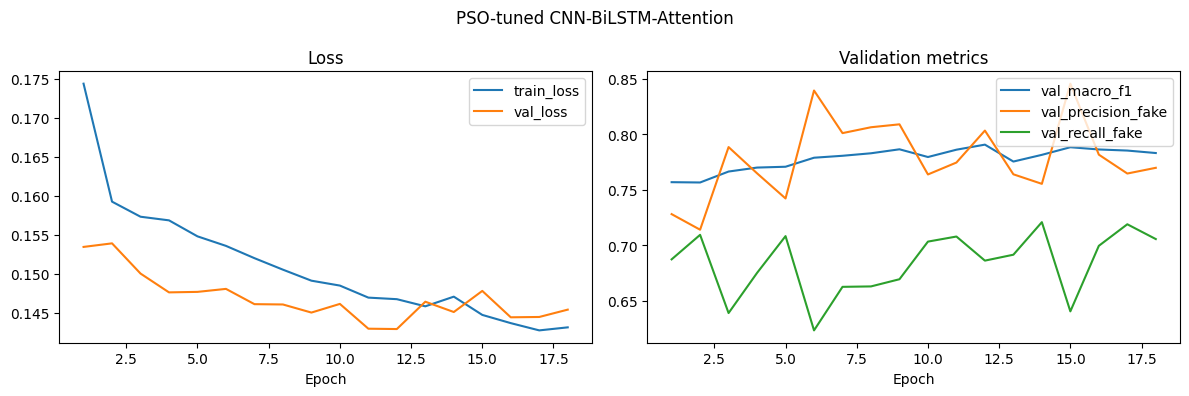

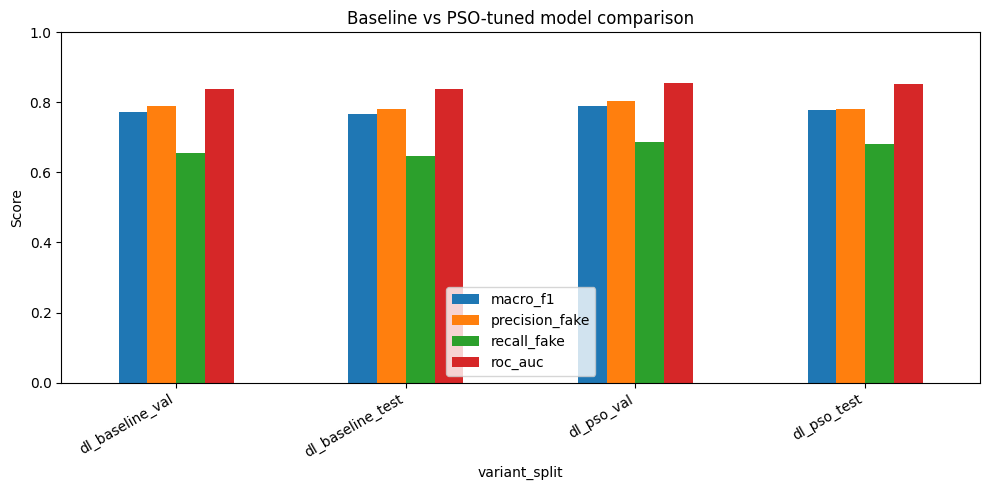

,generated_at_utc,seed,split,model_variant,threshold,loss,accuracy,macro_f1,precision_fake,recall_fake,f1_fake,support_real,support_fake,roc_auc,pr_auc,tn,fp,fn,tp,probability_path
0,2026-06-01T08:09:11.977160+00:00,42,train,dl_baseline,0.5,0.118537,0.787020,0.772678,0.788997,0.654663,0.715580,17677,12246,0.842763,0.830222,15533,2144,4229,8017,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...
1,2026-06-01T08:09:12.695418+00:00,42,val,dl_baseline,0.5,0.118063,0.787931,0.773722,0.789643,0.656631,0.717020,3789,2624,0.838348,0.829885,3330,459,901,1723,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...
2,2026-06-01T08:09:13.281155+00:00,42,test,dl_baseline,0.5,0.119523,0.781382,0.766460,0.781827,0.645960,0.707429,3789,2624,0.838937,0.824163,3316,473,929,1695,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...
3,2026-06-01T08:34:57.244532+00:00,42,train,dl_pso,0.5,0.139977,0.807138,0.795418,0.807893,0.693696,0.746452,17677,12246,0.864862,0.852753,15657,2020,3751,8495,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...
4,2026-06-01T08:34:58.484983+00:00,42,val,dl_pso,0.5,0.142886,0.802744,0.790540,0.803213,0.685976,0.739979,3789,2624,0.855308,0.844920,3348,441,824,1800,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...
5,2026-06-01T08:34:59.559173+00:00,42,test,dl_pso,0.5,0.146141,0.791517,0.779349,0.781866,0.680259,0.727532,3789,2624,0.851668,0.836069,3291,498,839,1785,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...


In [14]:
# best_params_payload: đọc hyperparameter tốt nhất từ PSO
with BEST_PARAMS_PATH.open("r", encoding="utf-8") as file:
    # best_params_payload = ...: parse nội dung JSON
    best_params_payload = json.load(file)

# PSO_BEST_CONFIG: cấu hình decode từ PSO để train model cuối
PSO_BEST_CONFIG = best_params_payload["decoded_best_params"]
# PSO_BEST_CONFIG["batch_size"] = capped_batch_size(int(PSO_BEST_CONFIG.get("batch...: ép kiểu số nguyên
PSO_BEST_CONFIG["batch_size"] = capped_batch_size(int(PSO_BEST_CONFIG.get("batch_size", DEFAULT_BATCH_SIZE)))

# pso_train_loader = ...: gán giá trị cho biến pso train loader
pso_train_loader = make_loader(X["train"], y["train"], PSO_BEST_CONFIG["batch_size"], shuffle=True)
# pso_val_loader = ...: gán giá trị cho biến pso val loader
pso_val_loader = make_loader(X["val"], y["val"], PSO_BEST_CONFIG["batch_size"], shuffle=False)
# pso_test_loader = ...: gán giá trị cho biến pso test loader
pso_test_loader = make_loader(X["test"], y["test"], PSO_BEST_CONFIG["batch_size"], shuffle=False)

# pso_model, pso_history_df, pso_best_metrics = fit_model(: fit model/reducer trên dữ liệu train
pso_model, pso_history_df, pso_best_metrics = fit_model(
    # config = ...: gán giá trị cho biến config
    config=PSO_BEST_CONFIG,
    # train_data_loader = ...: gán giá trị cho biến train data loader
    train_data_loader=pso_train_loader,
    # validation_data_loader = ...: gán giá trị cho biến validation data loader
    validation_data_loader=pso_val_loader,
    # class_weights = ...: gán giá trị cho biến class weights
    class_weights=CLASS_WEIGHTS,
    # input_dim = ...: gán giá trị cho biến input dim
    input_dim=INPUT_DIM,
    # model_variant = ...: gán giá trị cho biến model variant
    model_variant="dl_pso",
    # max_epochs = ...: lấy giá trị lớn nhất
    max_epochs=FINAL_MAX_EPOCHS,
    # patience = ...: gán giá trị cho biến patience
    patience=EARLY_STOPPING_PATIENCE,
    # verbose = ...: gán giá trị cho biến verbose
    verbose=True,
# ): đóng ngoặc gọi hàm
)

# torch.save(: thực thi lệnh Python
torch.save(
    # {: thực thi lệnh Python
    {
        # "model_variant": "dl_pso",: thực thi lệnh Python
        "model_variant": "dl_pso",
        # "seed": SEED,: thực thi lệnh Python
        "seed": SEED,
        # "input_dim": INPUT_DIM,: thực thi lệnh Python
        "input_dim": INPUT_DIM,
        # "config": PSO_BEST_CONFIG,: thực thi lệnh Python
        "config": PSO_BEST_CONFIG,
        # "class_weights": CLASS_WEIGHTS.tolist(),: chuyển/chiếu thành list
        "class_weights": CLASS_WEIGHTS.tolist(),
        # "best_validation_metrics": pso_best_metrics,: thực thi lệnh Python
        "best_validation_metrics": pso_best_metrics,
        # "model_state_dict": {key: value.detach().cpu() for key, value in pso_model.state...: tạo dictionary
        "model_state_dict": {key: value.detach().cpu() for key, value in pso_model.state_dict().items()},
    # },: đóng phần tử từ điển (còn phần tử sau)
    },
    # BEST_MODEL_PATH,: thực thi lệnh Python
    BEST_MODEL_PATH,
# ): đóng ngoặc gọi hàm
)

# pso_history_path = ...: gán giá trị cho biến pso history path
pso_history_path = REPORT_TABLE_DIR / "phase4_pso_training_history.csv"
# pso_history_df.to_csv(pso_history_path, index=False): ghi DataFrame ra file CSV
pso_history_df.to_csv(pso_history_path, index=False)

# pso_metrics_rows = ...: gán giá trị cho biến pso metrics rows
pso_metrics_rows = []
# pso_criterion = ...: gán giá trị cho biến pso criterion
pso_criterion = FocalLoss(alpha=CLASS_WEIGHTS.to(DEVICE), gamma=PSO_BEST_CONFIG["focal_gamma"])
# for: vòng lặp — for split, loader in [
for split, loader in [
    # ("train", pso_train_loader),: thực thi lệnh Python
    ("train", pso_train_loader),
    # ("val", pso_val_loader),: thực thi lệnh Python
    ("val", pso_val_loader),
    # ("test", pso_test_loader),: thực thi lệnh Python
    ("test", pso_test_loader),
# ]:: thực thi lệnh Python
]:
    # metrics, prob_fake, _ = evaluate_model(pso_model, loader, pso_criterion, split, ...: thực thi lệnh Python
    metrics, prob_fake, _ = evaluate_model(pso_model, loader, pso_criterion, split, "dl_pso")
    # metrics["probability_path"] = save_probabilities(prob_fake, split, "dl_pso"): thực thi lệnh Python
    metrics["probability_path"] = save_probabilities(prob_fake, split, "dl_pso")
    # pso_metrics_rows.append(metrics): thực thi lệnh Python
    pso_metrics_rows.append(metrics)

# pso_metrics_df = ...: gán giá trị cho biến pso metrics df
pso_metrics_df = pd.DataFrame(pso_metrics_rows)
# pso_final_metrics_path = ...: gán giá trị cho biến pso final metrics path
pso_final_metrics_path = REPORT_TABLE_DIR / "phase4_pso_final_metrics.csv"
# pso_metrics_df.to_csv(pso_final_metrics_path, index=False): ghi DataFrame ra file CSV
pso_metrics_df.to_csv(pso_final_metrics_path, index=False)

# baseline_metrics_path = ...: gán giá trị cho biến baseline metrics path
baseline_metrics_path = REPORT_TABLE_DIR / "phase4_baseline_metrics.csv"
# if: điều kiện — if baseline_metrics_path.exists():
if baseline_metrics_path.exists():
    # baseline_metrics_for_comparison = ...: đọc file CSV vào DataFrame
    baseline_metrics_for_comparison = pd.read_csv(baseline_metrics_path)
# else: nhánh còn lại của điều kiện
else:
    # baseline_metrics_for_comparison = ...: gán giá trị cho biến baseline metrics for comparison
    baseline_metrics_for_comparison = pd.DataFrame()

# comparison_df = ...: nối nhiều DataFrame
comparison_df = pd.concat(
    # [baseline_metrics_for_comparison, pso_metrics_df],: thực thi lệnh Python
    [baseline_metrics_for_comparison, pso_metrics_df],
    # axis = ...: gán giá trị cho biến axis
    axis=0,
    # ignore_index = ...: gán giá trị cho biến ignore index
    ignore_index=True,
# ): đóng ngoặc gọi hàm
)
# comparison_path = ...: gán giá trị cho biến comparison path
comparison_path = REPORT_TABLE_DIR / "phase4_model_comparison.csv"
# comparison_df.to_csv(comparison_path, index=False): ghi DataFrame ra file CSV
comparison_df.to_csv(comparison_path, index=False)

# plot_training_history(: thực thi lệnh Python
plot_training_history(
    # pso_history_df,: thực thi lệnh Python
    pso_history_df,
    # REPORT_FIGURE_DIR / "phase4_pso_training_curves.png",: thực thi lệnh Python
    REPORT_FIGURE_DIR / "phase4_pso_training_curves.png",
    # "PSO-tuned CNN-BiLSTM-Attention",: thực thi lệnh Python
    "PSO-tuned CNN-BiLSTM-Attention",
# ): đóng ngoặc gọi hàm
)

# metric_plot_df = ...: gán giá trị cho biến metric plot df
metric_plot_df = comparison_df[comparison_df["split"].isin(["val", "test"])].copy()
# if: điều kiện — if not metric_plot_df.empty:
if not metric_plot_df.empty:
    # metric_plot_df["variant_split"] = metric_plot_df["model_variant"] + "_" + metric...: thực thi lệnh Python
    metric_plot_df["variant_split"] = metric_plot_df["model_variant"] + "_" + metric_plot_df["split"]
    # ax = ...: tạo tập hợp
    ax = metric_plot_df.set_index("variant_split")[["macro_f1", "precision_fake", "recall_fake", "roc_auc"]].plot(
        # kind = ...: gán giá trị cho biến kind
        kind="bar",
        # figsize = ...: gán giá trị cho biến figsize
        figsize=(10, 5),
        # ylim = ...: gán giá trị cho biến ylim
        ylim=(0, 1),
    # ): đóng ngoặc gọi hàm
    )
    # ax.set_title("Baseline vs PSO-tuned model comparison"): xóa biến để giải phóng RAM/VRAM
    ax.set_title("Baseline vs PSO-tuned model comparison")
    # ax.set_ylabel("Score"): tạo tập hợp
    ax.set_ylabel("Score")
    # plt.xticks(rotation=30, ha="right"): thực thi lệnh Python
    plt.xticks(rotation=30, ha="right")
    # plt.tight_layout(): tự chỉnh lề biểu đồ
    plt.tight_layout()
    # plt.savefig(REPORT_FIGURE_DIR / "phase4_model_comparison.png", dpi=160, bbox_inc...: lưu biểu đồ ra file hình
    plt.savefig(REPORT_FIGURE_DIR / "phase4_model_comparison.png", dpi=160, bbox_inches="tight")
    # plt.show(): hiển thị biểu đồ
    plt.show()

# display(comparison_df): hiển thị bảng/kết quả trên notebook
display(comparison_df)


In [15]:
# phase4_metadata: JSON metadata đầy đủ cho Phase 5 ensemble
phase4_metadata = {
    # "generated_at_utc": utc_now(),: thực thi lệnh Python
    "generated_at_utc": utc_now(),
    # "seed": SEED,: thực thi lệnh Python
    "seed": SEED,
    # "project_root": str(PROJECT_ROOT),: ép kiểu chuỗi
    "project_root": str(PROJECT_ROOT),
    # "input_dim": INPUT_DIM,: thực thi lệnh Python
    "input_dim": INPUT_DIM,
    # "phase3_metadata_path": str(PHASE3_METADATA_PATH),: ép kiểu chuỗi
    "phase3_metadata_path": str(PHASE3_METADATA_PATH),
    # "phase3_reducer": phase3_metadata.get("reducer", {}),: thực thi lệnh Python
    "phase3_reducer": phase3_metadata.get("reducer", {}),
    # "phase3_input": phase3_metadata.get("input", {}),: thực thi lệnh Python
    "phase3_input": phase3_metadata.get("input", {}),
    # "baseline_config": BASELINE_CONFIG,: thực thi lệnh Python
    "baseline_config": BASELINE_CONFIG,
    # "best_pso_params": best_params_payload,: thực thi lệnh Python
    "best_pso_params": best_params_payload,
    # "guardrails": {: thực thi lệnh Python
    "guardrails": {
        # "max_batch_size": MAX_BATCH_SIZE,: lấy giá trị lớn nhất
        "max_batch_size": MAX_BATCH_SIZE,
        # "default_batch_size": DEFAULT_BATCH_SIZE,: thực thi lệnh Python
        "default_batch_size": DEFAULT_BATCH_SIZE,
        # "pso_subset_ratio": PSO_SUBSET_RATIO,: tạo tập hợp
        "pso_subset_ratio": PSO_SUBSET_RATIO,
        # "pso_particles": PSO_PARTICLES,: thực thi lệnh Python
        "pso_particles": PSO_PARTICLES,
        # "pso_iterations": PSO_ITERATIONS,: thực thi lệnh Python
        "pso_iterations": PSO_ITERATIONS,
        # "pso_trial_epochs": PSO_TRIAL_EPOCHS,: thực thi lệnh Python
        "pso_trial_epochs": PSO_TRIAL_EPOCHS,
        # "pso_search_space": PSO_SEARCH_SPACE,: thực thi lệnh Python
        "pso_search_space": PSO_SEARCH_SPACE,
        # "pso_objective_weights": PSO_OBJECTIVE_WEIGHTS,: thực thi lệnh Python
        "pso_objective_weights": PSO_OBJECTIVE_WEIGHTS,
        # "baseline_max_epochs": BASELINE_MAX_EPOCHS,: lấy giá trị lớn nhất
        "baseline_max_epochs": BASELINE_MAX_EPOCHS,
        # "final_max_epochs": FINAL_MAX_EPOCHS,: lấy giá trị lớn nhất
        "final_max_epochs": FINAL_MAX_EPOCHS,
        # "early_stopping_patience": EARLY_STOPPING_PATIENCE,: thực thi lệnh Python
        "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    # },: đóng phần tử từ điển (còn phần tử sau)
    },
    # "outputs": {: thực thi lệnh Python
    "outputs": {
        # "baseline_model": str(BASELINE_MODEL_PATH),: ép kiểu chuỗi
        "baseline_model": str(BASELINE_MODEL_PATH),
        # "best_model": str(BEST_MODEL_PATH),: ép kiểu chuỗi
        "best_model": str(BEST_MODEL_PATH),
        # "best_params": str(BEST_PARAMS_PATH),: ép kiểu chuỗi
        "best_params": str(BEST_PARAMS_PATH),
        # "phase4_metadata": str(PHASE4_METADATA_PATH),: ép kiểu chuỗi
        "phase4_metadata": str(PHASE4_METADATA_PATH),
        # "input_validation": str(REPORT_TABLE_DIR / "phase4_input_validation.csv"),: ép kiểu chuỗi
        "input_validation": str(REPORT_TABLE_DIR / "phase4_input_validation.csv"),
        # "baseline_metrics": str(REPORT_TABLE_DIR / "phase4_baseline_metrics.csv"),: ép kiểu chuỗi
        "baseline_metrics": str(REPORT_TABLE_DIR / "phase4_baseline_metrics.csv"),
        # "baseline_history": str(REPORT_TABLE_DIR / "phase4_baseline_training_history.csv...: ép kiểu chuỗi
        "baseline_history": str(REPORT_TABLE_DIR / "phase4_baseline_training_history.csv"),
        # "pso_trial_history": str(REPORT_TABLE_DIR / "phase4_pso_trial_history.csv"),: ép kiểu chuỗi
        "pso_trial_history": str(REPORT_TABLE_DIR / "phase4_pso_trial_history.csv"),
        # "pso_final_metrics": str(REPORT_TABLE_DIR / "phase4_pso_final_metrics.csv"),: ép kiểu chuỗi
        "pso_final_metrics": str(REPORT_TABLE_DIR / "phase4_pso_final_metrics.csv"),
        # "model_comparison": str(REPORT_TABLE_DIR / "phase4_model_comparison.csv"),: ép kiểu chuỗi
        "model_comparison": str(REPORT_TABLE_DIR / "phase4_model_comparison.csv"),
        # "baseline_val_prob": str(PREDICTION_DIR / "dl_baseline_val_prob.npy"),: ép kiểu chuỗi
        "baseline_val_prob": str(PREDICTION_DIR / "dl_baseline_val_prob.npy"),
        # "baseline_test_prob": str(PREDICTION_DIR / "dl_baseline_test_prob.npy"),: ép kiểu chuỗi
        "baseline_test_prob": str(PREDICTION_DIR / "dl_baseline_test_prob.npy"),
        # "pso_train_prob": str(PREDICTION_DIR / "dl_pso_train_prob.npy"),: ép kiểu chuỗi
        "pso_train_prob": str(PREDICTION_DIR / "dl_pso_train_prob.npy"),
        # "pso_val_prob": str(PREDICTION_DIR / "dl_pso_val_prob.npy"),: ép kiểu chuỗi
        "pso_val_prob": str(PREDICTION_DIR / "dl_pso_val_prob.npy"),
        # "pso_test_prob": str(PREDICTION_DIR / "dl_pso_test_prob.npy"),: ép kiểu chuỗi
        "pso_test_prob": str(PREDICTION_DIR / "dl_pso_test_prob.npy"),
        # "baseline_training_curves": str(REPORT_FIGURE_DIR / "phase4_baseline_training_cu...: ép kiểu chuỗi
        "baseline_training_curves": str(REPORT_FIGURE_DIR / "phase4_baseline_training_curves.png"),
        # "pso_objective_history": str(REPORT_FIGURE_DIR / "phase4_pso_objective_history.p...: ép kiểu chuỗi
        "pso_objective_history": str(REPORT_FIGURE_DIR / "phase4_pso_objective_history.png"),
        # "pso_training_curves": str(REPORT_FIGURE_DIR / "phase4_pso_training_curves.png")...: ép kiểu chuỗi
        "pso_training_curves": str(REPORT_FIGURE_DIR / "phase4_pso_training_curves.png"),
        # "model_comparison_figure": str(REPORT_FIGURE_DIR / "phase4_model_comparison.png"...: ép kiểu chuỗi
        "model_comparison_figure": str(REPORT_FIGURE_DIR / "phase4_model_comparison.png"),
    # },: đóng phần tử từ điển (còn phần tử sau)
    },
    # "environment": environment_versions(),: thực thi lệnh Python
    "environment": environment_versions(),
# }: đóng khối từ điển
}

# with: context manager — with PHASE4_METADATA_PATH.open("w", encoding="utf-8") as fil
with PHASE4_METADATA_PATH.open("w", encoding="utf-8") as file:
    # json.dump(phase4_metadata, file, indent=2): ghi dictionary ra JSON
    json.dump(phase4_metadata, file, indent=2)

# print("Saved Phase 4 metadata:", PHASE4_METADATA_PATH): in thông tin ra console
print("Saved Phase 4 metadata:", PHASE4_METADATA_PATH)


Saved Phase 4 metadata: /content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/artifacts/models/phase4_metadata.json


## Phase 4 Checklist

- [x] Legacy PSO CNN-BiLSTM-Attention path is retained for ablation evidence.
- [x] Notebook remains Colab-only and keeps batch/PSO guardrails.
- [x] Revised final DL candidates are moved to Phase 5 per-model notebooks.
- [x] Phase 7 must not overclaim this PCA/static-vector DL path as the final architecture.
